# Building intraday features from three shapes of quote data

BondCliQ is the rawest shape: one record every time a dealer quotes. In practice two snapshot shapes are far more common, and **neither normally tells you which dealer is behind a level** — that is the case this notebook is about (dealer-named snapshots are handled by the same code but treated as a rare reference case):

| Shape | One row is | What it keeps | What it loses |
|---|---|---|---|
| **A. Dealer event stream** (BondCliQ) | dealer × side × timestamp | everything: dealer identity, each dealer's full history, exact timestamps, size | — |
| **B. TOB snapshot** | best bid / best ask per (bond, grid time), possibly with size, with each side's last update time | best level, freshness, (optional) size, (optional) who is on top | the other dealers, depth, dispersion; grid delay |
| **C. 5-level ladder snapshot** | levels 1–5 per side per (bond, grid time), possibly with size per level, with the ladder's oldest / newest update time | depth, dispersion, where CPP sits in the quote distribution | dealer identity (usually), per-level timestamps; **a level is a rank, not a dealer** |

This notebook does three things:

1. Converts the BondCliQ event stream into shapes B and C (`dealer_state_to_tob` / `dealer_state_to_ladder`, §2.1 / §3.1), so all three shapes can be compared on the **same prints**;
2. Gives two feature routes for each shape:
   - **Route 1 (back to events)**: turn the snapshot into the canonical event stream and reuse the dealer engine of shape A (§1) with pseudo-dealers (`TOB`, `L{k}`) standing in for the unknown dealers. Feature names stay identical to shape A, but every "chained" move becomes a per-rank change;
   - **Route 2 (native snapshot features)**: as-of alignment directly on the snapshot table (`tob_features_at_prints` / `ladder_features_at_prints`, §2.2 / §3.2). Built for the no-identity case; freshness and level features survive, dynamic features are composition-noisy;
3. Discusses how price- / yield-quoted data enters the same framework, and quantifies the information gap between the three shapes with walk-forward LightGBM on the same prints.

Every feature obeys the same point-in-time rule: only snapshots / quotes stamped **strictly before** the print time (minus an optional availability lag). Design rationale is in `report/reports/006-quote-feature-pipeline.md`.

The notebook is standalone: it needs only `numpy`, `pandas`, `lightgbm` and `matplotlib`. All feature code is defined inline, in the section where it is first used (the same functions are kept in `bcq_features.py` / `quote_snapshots.py` for use outside the notebook).

## 0. Setup

Imports, paths, the evaluation helpers shared by every shape (walk-forward folds, LightGBM fit with early stopping, MAE in bps, paired-by-day test), and the first piece of library code: reading the dealer event stream into a canonical long table and collapsing it into a **dealer state table**.

`state` has one row per (bond, dealer, timestamp): both sides of a same-time update combined, one-sided updates carrying the other side forward within the day (with that side's own timestamp), a width filter that blanks the mid of crossed / over-wide two-sided quotes, and cumulative per-dealer counters so that any window statistic later becomes a difference of two as-of lookups. It is the starting point of every conversion below.

In [1]:
import time, warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Iterable

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")
pd.set_option("display.width", 200, "display.max_columns", 60)

QUOTES = "received/filtered_issuers_100_110.parquet"     # BondCliQ dealer events, 100-110 issuer slice, Mar 2026
PRINTS = "received/filtered_data_ig_100_110.parquet"     # trace prints for the same bonds / period

In [2]:
# ---- evaluation helpers (same parameters as the harness bcq_intraday_eval.py) ----
BASE_FEATURES = [
    "D_CPP_BM_SPREAD", "COUPON", "D_CDX_TRADE", "MEAN_ISSUER_SPREAD_DEV", "NUM_OF_ISSUER_TRADES_SINCE_PREV",
    "PREV_BM_SPREAD", "PREV_QUANTITY", "PREV_TRADE_TYPE", "QUANTITY", "TRADE_TYPE", "YRS_TO_MATURITY",
    "BM_YIELD_STD", "D_SHORT_TO_BM_SPREAD", "PREV_BM_SPREAD_STD_GROUP_BY_TYPE",
]


CAT_FEATURES = ["PREV_TRADE_TYPE", "TRADE_TYPE"]


TARGET = "D_BM_SPREAD"


LGB_PARAMS = dict(objective="mae", boosting_type="gbdt", learning_rate=0.05, n_estimators=2000, num_leaves=31,
                  min_child_samples=50, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                  max_bin=255, n_jobs=-1, verbosity=-1, random_state=7)


def _folds(dates: list, n_folds: int, test_days: int, val_days: int, embargo: int):
    dates = sorted(dates)
    out = []
    for k in range(n_folds):
        test_end = len(dates) - (n_folds - 1 - k) * test_days
        test = dates[test_end - test_days:test_end]
        val = dates[max(0, test_end - test_days - val_days):test_end - test_days]
        train = dates[:max(0, test_end - test_days - val_days - embargo)]
        if train and val and test:
            out.append((k + 1, train, val, test))
    return out


def _fit(df, tr, va, feats, cats):
    import lightgbm as lgb
    m = lgb.LGBMRegressor(**LGB_PARAMS)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m.fit(df.loc[tr, feats], df.loc[tr, TARGET], eval_set=[(df.loc[va, feats], df.loc[va, TARGET])], eval_metric="l1",
              callbacks=[lgb.early_stopping(100, verbose=False)], categorical_feature=[c for c in cats if c in feats])
    return m


def _mae(a, b):
    return float(np.nanmean(np.abs(np.asarray(a) - np.asarray(b))) * 100.0)  # bps


def _paired_by_day(df, col_a, col_b, y=TARGET):
    ea = (df[col_a] - df[y]).abs().groupby(df["DATE"]).mean()
    eb = (df[col_b] - df[y]).abs().groupby(df["DATE"]).mean()
    d = (ea - eb) * 100.0
    return dict(days=int(len(d)), mean_gain_bps=float(d.mean()), t_stat=float(d.mean() / d.std(ddof=1) * np.sqrt(len(d))) if len(d) > 1 else np.nan,
                share_days_better=float((d > 0).mean()))

In [3]:
# ---- library: dealer quote events -> canonical table -> dealer state ----
CANONICAL_COLS = ["cusip", "firm", "ts", "side", "price_type", "spread", "price", "quantity"]


def load_dealer_quotes(paths: Iterable[str | Path]) -> pd.DataFrame:
    """Read issuer parquet files (one row per dealer x side x timestamp) into the canonical layout."""
    q = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)
    q = q.rename(columns={"quote_timestamp_UTC": "ts"})
    q["ts"] = pd.to_datetime(q["ts"], utc=True)
    q["side"] = q["side"].astype(str).str.lower()
    q["price_type"] = q["price_type"].astype(str).str.lower()
    for c in ("spread", "price", "quantity"):
        q[c] = pd.to_numeric(q[c], errors="coerce")
    extra = [c for c in ("issuer",) if c in q.columns]
    return q[CANONICAL_COLS + extra]


@dataclass(frozen=True)
class CleanConfig:
    price_types: tuple[str, ...] = ("spread",)
    min_width_bps: float = 0.0        # two-sided width below this (crossed) -> no mid/width
    max_width_bps: float = 30.0       # above this = different convention or placeholder -> no mid/width
    carry_one_sided_within_day: bool = True
    move_tolerance_bps: float = 1e-6  # |d mid| above this counts as a non-flat move


def build_dealer_state(quotes: pd.DataFrame, cfg: CleanConfig = CleanConfig()) -> pd.DataFrame:
    """Collapse the event stream into one row per (cusip, firm, ts) dealer state.

    * both sides of a same-timestamp update are combined; a one-sided update keeps
      the other side from the dealer's previous state on the same day, with that
      side's own timestamp (staleness is per side);
    * quantity 0 means "no size shown" and becomes NaN (units: MM);
    * two-sided states outside [min_width, max_width] keep their sides (they still
      count as activity) but get NaN mid/width, so levels ignore them;
    * cumulative per-dealer counters (updates, non-flat mid moves, signed move sum,
      widen/tighten counts, last move) make any window statistic a difference of
      two as-of lookups.
    """
    q = quotes[quotes["price_type"].isin(cfg.price_types) & quotes["spread"].notna()].copy()
    q["quantity"] = q["quantity"].where(q["quantity"] > 0)
    key = ["cusip", "firm", "ts"]
    q = q.sort_values(key, kind="stable").drop_duplicates(key + ["side"], keep="last")

    wide = q.pivot_table(index=key, columns="side", values=["spread", "quantity"], aggfunc="last")
    wide.columns = [b if a == "spread" else f"{b}_size" for a, b in wide.columns]
    wide = wide.reset_index()
    for c in ("bid", "ask", "bid_size", "ask_size"):
        if c not in wide.columns:
            wide[c] = np.nan
    bid_upd, ask_upd = wide["bid"].notna(), wide["ask"].notna()
    wide["bid_ts"] = wide["ts"].where(bid_upd)
    wide["ask_ts"] = wide["ts"].where(ask_upd)

    if cfg.carry_one_sided_within_day:
        day = wide["ts"].dt.tz_convert("America/New_York").dt.normalize()
        g_day = wide.groupby(["cusip", "firm", day], sort=False)
        for c in ("bid", "ask", "bid_size", "ask_size", "bid_ts", "ask_ts"):
            wide[c] = g_day[c].ffill()

    wide["width"] = wide["bid"] - wide["ask"]
    ok = wide["width"].between(cfg.min_width_bps, cfg.max_width_bps)
    wide["mid"] = ((wide["bid"] + wide["ask"]) / 2).where(ok)
    wide["width"] = wide["width"].where(ok)

    dealer = [wide["cusip"], wide["firm"]]
    g = wide.groupby(dealer, sort=False)
    wide["n_upd"] = g.cumcount() + 1
    wide["n_bid_upd"] = bid_upd.groupby(dealer).cumsum()
    wide["n_ask_upd"] = ask_upd.groupby(dealer).cumsum()
    d_mid = wide["mid"] - g["mid"].shift()
    moved = d_mid.abs().gt(cfg.move_tolerance_bps)
    wide["n_move"] = moved.groupby(dealer).cumsum()
    wide["signed_move_sum"] = d_mid.where(moved, 0.0).fillna(0.0).groupby(dealer).cumsum()
    wide["n_widen"] = (moved & d_mid.gt(0)).groupby(dealer).cumsum()
    wide["n_tighten"] = (moved & d_mid.lt(0)).groupby(dealer).cumsum()
    wide["last_move_ts"] = wide["ts"].where(moved).groupby(dealer).ffill()
    wide["last_move"] = d_mid.where(moved).groupby(dealer).ffill()
    return wide.sort_values(["firm", "cusip", "ts"], kind="stable").reset_index(drop=True)


def _to_utc(s: pd.Series, naive_tz: str = "America/New_York") -> pd.Series:
    t = pd.to_datetime(s, errors="coerce")
    if getattr(t.dt, "tz", None) is None:
        t = t.dt.tz_localize(naive_tz, ambiguous="NaT", nonexistent="shift_forward")
    return t.dt.tz_convert("UTC")

In [4]:
quotes = load_dealer_quotes([QUOTES])
state = build_dealer_state(quotes)
prints = pd.read_parquet(PRINTS).dropna(subset=["D_BM_SPREAD"]).reset_index(drop=True)
ts = _to_utc(prints["EFFECTIVE_DATETIME_TS"])
prints["DATE"] = ts.dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
prints["COVERED"] = prints["CUSIP"].astype(str).isin(set(state["cusip"].astype(str)))
for c in CAT_FEATURES:
    prints[c] = prints[c].astype("category")
folds = _folds(sorted(prints["DATE"].unique()), n_folds=3, test_days=3, val_days=3, embargo=1)

print(f"{len(quotes):,} quote events -> {len(state):,} dealer states, {state.cusip.nunique()} bonds, {state.firm.nunique()} dealers")
print(f"{len(prints):,} prints on {prints.DATE.nunique()} days, {prints.COVERED.mean():.0%} on quoted bonds")
print("folds (train/val/test days):", [(len(tr), len(va), len(te)) for _, tr, va, te in folds])
state.head(3)

759,246 quote events -> 396,351 dealer states, 222 bonds, 27 dealers
11,408 prints on 24 days, 100% on quoted bonds
folds (train/val/test days): [(11, 3, 3), (14, 3, 3), (17, 3, 3)]


,cusip,firm,ts,ask_size,bid_size,ask,bid,bid_ts,ask_ts,width,mid,n_upd,n_bid_upd,n_ask_upd,n_move,signed_move_sum,n_widen,n_tighten,last_move_ts,last_move
0,032095AQ4,096ed63d6de5,2026-03-02 12:49:23+00:00,NaN,NaN,52.0,57.0,2026-03-02 12:49:23+00:00,2026-03-02 12:49:23+00:00,5.0,54.5,1,1,1,0,0.0,0,0,NaT,NaN
1,032095AQ4,096ed63d6de5,2026-03-09 11:38:21+00:00,NaN,NaN,52.0,57.0,2026-03-09 11:38:21+00:00,2026-03-09 11:38:21+00:00,5.0,54.5,2,2,2,0,0.0,0,0,NaT,NaN
2,032095AQ4,096ed63d6de5,2026-03-16 11:30:15+00:00,NaN,NaN,60.0,65.0,2026-03-16 11:30:15+00:00,2026-03-16 11:30:15+00:00,5.0,62.5,3,3,3,1,8.0,1,0,2026-03-16 11:30:15+00:00,8.0


## 1. Shape A: the dealer event stream (recap)

This is the route already worked through in reports 005 / 006: `build_dealer_state` → `build_bcq_features`. One `merge_asof` gives the as-of state of every dealer at print time as a (print × dealer) matrix; statistics are then taken along the dealer axis. Key design choices:

* **levels** use the cross-dealer median, dropping dealers with abnormal widths or far from the median; the TOB is uncrossed by staleness;
* **dynamics** use the median of "same-dealer chained changes" — only dealers quoting at both ends of the window count, each with its own change — which avoids the spurious mean reversion caused by dealers entering and leaving;
* two second-stage features exist only for this shape: the **debiased consensus** (each (bond, dealer)'s systematic bias against past prints) and **issuer-level dynamics** (chained moves on the issuer's other bonds).

The engine is defined in the next two cells (as-of snapshot matrices, dealer-axis aggregations, and the two second-stage features), then run once as the reference.

In [5]:
# ---- library: point-in-time dealer engine ----
@dataclass(frozen=True)
class FeatureConfig:
    availability_lag: pd.Timedelta = pd.Timedelta(0)     # quotes must be stamped < t - lag
    max_quote_age: pd.Timedelta = pd.Timedelta("60min")  # a side is "active" if at most this old (120min worked best)
    level_outlier_bps: float = 15.0                      # distance to the cross-dealer median beyond which a level is dropped
    windows: tuple[tuple[str, pd.Timedelta], ...] = (("30M", pd.Timedelta("30min")), ("2H", pd.Timedelta("2h")))
    include_since_prev: bool = True                      # also measure everything between the previous print and now
    chunk_rows: int = 50_000
    # print columns
    cusip_col: str = "CUSIP"
    trade_time_col: str = "EFFECTIVE_DATETIME_TS"
    prev_time_col: str = "PREV_EFFECTIVE_DATETIME_TS_x"
    trade_type_col: str = "TRADE_TYPE"
    quantity_col: str = "QUANTITY"
    prev_bm_spread_col: str = "PREV_BM_SPREAD"           # model coordinate: level - prev + offset (all in %)
    bm_offset_col: str = "D_BM_YIELD_OFFSET"
    cpp_bid_col: str = "BID_SPREAD_CPP"
    cpp_ask_col: str = "ASK_SPREAD_CPP"
    cpp_mid_col: str = "MID_SPREAD_CPP"
    cpp_time_col: str = "LASTUPDATETIME_CPP"


def _epoch_s(t: pd.Series) -> np.ndarray:
    return (t.astype("int64").astype("float64") / 1e9).to_numpy()


def _nanmedian_rows(a: np.ndarray) -> np.ndarray:
    with np.errstate(all="ignore"), warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.nanmedian(a, axis=1)


def _chunk_rows(cfg: FeatureConfig, n_firms: int) -> int:
    """Each snapshot holds ~30 (rows x firms) float64 matrices; keep a chunk under ~0.5 GB."""
    return int(min(cfg.chunk_rows, max(2_000, 2_000_000 // max(1, n_firms))))


def _model_coord(level_pct: np.ndarray | pd.Series, obs: pd.DataFrame, cfg: FeatureConfig):
    """level (%) -> the model's D_* coordinate: level - PREV_BM_SPREAD + D_BM_YIELD_OFFSET."""
    prev = pd.to_numeric(obs[cfg.prev_bm_spread_col], errors="coerce")
    off = pd.to_numeric(obs[cfg.bm_offset_col], errors="coerce").fillna(0.0) if cfg.bm_offset_col in obs.columns else pd.Series(0.0, index=obs.index)
    if isinstance(level_pct, pd.Series):
        return level_pct - prev + off
    return level_pct - prev.to_numpy() + off.to_numpy()


def _by_side(tt: np.ndarray, bid, ask, mid):
    """Pick the customer's side: B (customer sells) -> bid, S -> ask, D -> mid."""
    return np.where(tt == "B", bid, np.where(tt == "S", ask, mid))


_LOOKUP_COLS = ["bid", "ask", "mid", "width", "bid_size", "ask_size", "bid_ts_s", "ask_ts_s",
                "n_upd", "n_bid_upd", "n_ask_upd", "n_move", "signed_move_sum", "n_widen", "n_tighten", "last_move_ts_s", "last_move"]


def _prep_state_by_firm(state: pd.DataFrame) -> tuple[dict[str, pd.DataFrame], list[str]]:
    """Split the state table per firm, with epoch-second copies of the timestamps for vectorised age arithmetic."""
    st = state.copy()
    st["cusip"] = st["cusip"].astype(str)
    st["firm"] = st["firm"].astype(str)
    for c in ("ts", "bid_ts", "ask_ts", "last_move_ts"):
        st[c] = pd.to_datetime(st[c], utc=True)
    for c in ("bid_ts", "ask_ts", "last_move_ts"):
        st[c + "_s"] = st[c].astype("int64").where(st[c].notna()).astype("float64") / 1e9
    firms = sorted(st["firm"].unique())
    by = {f: g.sort_values("ts", kind="stable").reset_index(drop=True) for f, g in st.groupby("firm", sort=False)}
    return by, firms


def _asof_matrix(obs: pd.DataFrame, by: dict[str, pd.DataFrame], firms: list[str], t_query: pd.Series,
                 cols: list[str]) -> dict[str, np.ndarray]:
    """As-of lookup (strictly before t_query) per firm -> {col: (n_obs, n_firms) array}."""
    n = len(obs)
    out = {c: np.full((n, len(firms)), np.nan, dtype="float64") for c in cols}
    left = pd.DataFrame({"cusip": obs["_cusip"].to_numpy(), "_t": t_query.to_numpy(), "_i": np.arange(n)})
    left = left.dropna(subset=["_t"]).sort_values("_t", kind="stable")
    for j, f in enumerate(firms):
        m = pd.merge_asof(left, by[f][["cusip", "ts", *cols]], left_on="_t", right_on="ts", by="cusip",
                          direction="backward", allow_exact_matches=False)
        idx = m["_i"].to_numpy()
        for c in cols:
            out[c][idx, j] = m[c].to_numpy(dtype="float64", na_value=np.nan)
    return out


def _snapshot(obs: pd.DataFrame, by: dict[str, pd.DataFrame], firms: list[str], t_query: pd.Series,
              cfg: FeatureConfig) -> dict[str, np.ndarray]:
    """State matrices at ``t_query`` with three nested masks applied.

    activity  bid/ask/sizes: side present and at most ``max_quote_age`` old (counts use this)
    level     mid/width/bid_lvl/ask_lvl: additionally within ``level_outlier_bps`` of the
              cross-dealer median, and not a dealer whose own width failed the convention filter
    tob       bid_tob/ask_tob: level quotes after uncrossing by staleness
    Also returns per-side ages and the first (raw) crossing's direction and depth.
    """
    M = _asof_matrix(obs, by, firms, t_query, _LOOKUP_COLS)
    tq = _epoch_s(t_query)[:, None]
    max_age = cfg.max_quote_age.total_seconds()
    age_bid, age_ask = tq - M["bid_ts_s"], tq - M["ask_ts_s"]
    bid_ok = np.isfinite(M["bid"]) & (age_bid <= max_age)
    ask_ok = np.isfinite(M["ask"]) & (age_ask <= max_age)
    M["bid"] = np.where(bid_ok, M["bid"], np.nan)
    M["ask"] = np.where(ask_ok, M["ask"], np.nan)
    M["bid_size"] = np.where(bid_ok, M["bid_size"], np.nan)
    M["ask_size"] = np.where(ask_ok, M["ask_size"], np.nan)
    two = bid_ok & ask_ok & np.isfinite(M["mid"])
    M["mid"] = np.where(two, M["mid"], np.nan)
    M["width"] = np.where(two, M["width"], np.nan)
    M["age_bid"] = np.where(bid_ok, age_bid, np.nan)
    M["age_ask"] = np.where(ask_ok, age_ask, np.nan)
    M["age_any"] = np.fmin(M["age_bid"], M["age_ask"])

    # level mask: far from the median, or a two-sided dealer whose width failed the filter (its
    # mid is NaN, so the mid-based test cannot see it -- exclude its sides explicitly)
    far = np.abs(M["mid"] - _nanmedian_rows(M["mid"])[:, None]) > cfg.level_outlier_bps
    bad_pair = bid_ok & ask_ok & ~np.isfinite(M["mid"])
    M["mid"] = np.where(far, np.nan, M["mid"])
    M["width"] = np.where(far, np.nan, M["width"])
    bid_lvl = np.where(far | bad_pair, np.nan, M["bid"])
    ask_lvl = np.where(far | bad_pair, np.nan, M["ask"])
    # per-side outlier test catches one-sided dealers, which have no mid
    bid_lvl = np.where(np.abs(bid_lvl - _nanmedian_rows(bid_lvl)[:, None]) > cfg.level_outlier_bps, np.nan, bid_lvl)
    ask_lvl = np.where(np.abs(ask_lvl - _nanmedian_rows(ask_lvl)[:, None]) > cfg.level_outlier_bps, np.nan, ask_lvl)
    M["bid_lvl"], M["ask_lvl"] = bid_lvl, ask_lvl
    M["bid_tob"], M["ask_tob"], M["cross_dir"], M["cross_depth"] = _uncross_by_staleness(bid_lvl, ask_lvl, M["age_bid"], M["age_ask"])
    return M


def _uncross_by_staleness(bid: np.ndarray, ask: np.ndarray, age_bid: np.ndarray, age_ask: np.ndarray):
    """Best bid (min spread) below best ask (max spread) = dealers crossed each other.

    A crossing is almost always one fresh quote through another dealer's stale one, so
    the *older* of the two crossing quotes is dropped, repeatedly, until uncrossed.
    Returns the uncrossed bid/ask matrices and, from the first (raw) crossing:
      cross_dir    -1 fresh bid through stale asks (buying pressure), +1 fresh ask through
                   stale bids (selling pressure), 0 not crossed
      cross_depth  bps through (>= 0)
    """
    bid, ask = bid.copy(), ask.copy()
    n, k = bid.shape
    rows = np.arange(n)
    cross_dir, cross_depth = np.zeros(n), np.zeros(n)
    first = True
    for _ in range(k):
        ib = np.argmin(np.where(np.isfinite(bid), bid, np.inf), axis=1)
        ia = np.argmax(np.where(np.isfinite(ask), ask, -np.inf), axis=1)
        bb, ba = bid[rows, ib], ask[rows, ia]
        crossed = np.isfinite(bb) & np.isfinite(ba) & (bb < ba)
        if not crossed.any():
            break
        bid_fresher = crossed & (age_bid[rows, ib] < age_ask[rows, ia])
        ask_fresher = crossed & ~bid_fresher
        if first:
            cross_depth = np.where(crossed, ba - bb, 0.0)
            cross_dir = np.where(bid_fresher, -1.0, np.where(ask_fresher, 1.0, 0.0))
            first = False
        ask[rows[bid_fresher], ia[bid_fresher]] = np.nan     # stale ask goes
        bid[rows[ask_fresher], ib[ask_fresher]] = np.nan     # stale bid goes
    return bid, ask, cross_dir, cross_depth


def _chained(now: dict, then: dict, col: str) -> tuple[np.ndarray, np.ndarray]:
    """Same-dealer change between two snapshots: median over dealers present at both ends, and their count."""
    d = now[col] - then[col]
    return _nanmedian_rows(d), np.isfinite(d).sum(axis=1).astype("float64")


def _counter_diff(now: dict, then: dict, col: str) -> np.ndarray:
    return np.nan_to_num(now[col]) - np.nan_to_num(then[col])


def _window_dynamics(now: dict, then: dict, prefix: str, out: dict) -> None:
    """Update-flow statistics between two snapshots from the cumulative counters."""
    upd = _counter_diff(now, then, "n_upd")
    d_bid, d_ask = _counter_diff(now, then, "n_bid_upd").sum(axis=1), _counter_diff(now, then, "n_ask_upd").sum(axis=1)
    moves = _counter_diff(now, then, "n_move")
    signed = _counter_diff(now, then, "signed_move_sum")
    widen, tight = _counter_diff(now, then, "n_widen").sum(axis=1), _counter_diff(now, then, "n_tighten").sum(axis=1)
    n_moved = (moves > 0).sum(axis=1).astype("float64")
    out[f"BCQ_N_UPDATES_{prefix}"] = upd.sum(axis=1)
    out[f"BCQ_N_FIRMS_UPDATING_{prefix}"] = (upd > 0).sum(axis=1).astype("float64")
    out[f"BCQ_N_FIRMS_MOVED_{prefix}"] = n_moved
    out[f"BCQ_SIGNED_MOVE_SUM_{prefix}"] = signed.sum(axis=1) / 100.0
    with np.errstate(all="ignore"):
        out[f"BCQ_UPDATE_IMBALANCE_{prefix}"] = np.where(d_bid + d_ask > 0, (d_bid - d_ask) / (d_bid + d_ask), np.nan)
        out[f"BCQ_SHARE_WIDER_{prefix}"] = np.where(widen + tight > 0, widen / (widen + tight), np.nan)
        # mean over dealers that moved of the sign of their net move: -1 all tighter .. +1 all wider
        net_sign = np.sign(signed) * (moves > 0)
        out[f"BCQ_MOVE_BREADTH_{prefix}"] = np.where(n_moved > 0, net_sign.sum(axis=1) / n_moved, np.nan)


def build_bcq_features(prints: pd.DataFrame, state: pd.DataFrame, cfg: FeatureConfig = FeatureConfig()) -> pd.DataFrame:
    """Return ``prints`` (original order and index) with ``BCQ_*`` columns appended.

    Prints whose CUSIP has no quotes get NaN in every feature, so a model can be
    trained on the full print universe (LightGBM branches on NaN) and evaluated
    on the covered subset.
    """
    by, firms = _prep_state_by_firm(state)
    covered = set(state["cusip"].astype(str).unique())

    P = prints.copy()
    P["_cusip"] = P[cfg.cusip_col].astype(str)
    P["_t"] = _to_utc(P[cfg.trade_time_col]) - cfg.availability_lag
    if cfg.include_since_prev:
        if cfg.prev_time_col in P.columns:
            P["_t_prev"] = _to_utc(P[cfg.prev_time_col]) - cfg.availability_lag
        else:
            P["_t_prev"] = P.sort_values("_t").groupby("_cusip")["_t"].shift().reindex(P.index)
    work = P.loc[P["_cusip"].isin(covered) & P["_t"].notna()]

    feats = []
    step = _chunk_rows(cfg, len(firms))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)   # all-NaN rows (no active dealer) are expected
        for start in range(0, len(work), step):
            feats.append(_features_for_chunk(work.iloc[start:start + step], by, firms, cfg))
    F = pd.concat(feats) if feats else pd.DataFrame(index=work.index)
    return pd.concat([prints, F.reindex(P.index)], axis=1)


def _features_for_chunk(obs: pd.DataFrame, by, firms, cfg: FeatureConfig) -> pd.DataFrame:
    out: dict[str, np.ndarray] = {}
    now = _snapshot(obs, by, firms, obs["_t"], cfg)
    tt = obs[cfg.trade_type_col].astype(str).to_numpy() if cfg.trade_type_col in obs.columns else np.full(len(obs), "D")

    # ---- participation / depth ----
    has_bid, has_ask = np.isfinite(now["bid"]), np.isfinite(now["ask"])
    n_bid, n_ask = has_bid.sum(axis=1).astype("float64"), has_ask.sum(axis=1).astype("float64")
    n_two = np.isfinite(now["mid"]).sum(axis=1).astype("float64")
    n_any = (has_bid | has_ask).sum(axis=1).astype("float64")
    sb, sa = np.nansum(now["bid_size"], axis=1), np.nansum(now["ask_size"], axis=1)
    known = np.isfinite(now["bid_size"]).sum(axis=1) + np.isfinite(now["ask_size"]).sum(axis=1)
    out["BCQ_N_DEALERS"] = n_any
    out["BCQ_N_TWO_SIDED"] = n_two
    out["BCQ_SIZE_BID_MM"] = np.where(np.isfinite(now["bid_size"]).any(axis=1), sb, np.nan)
    out["BCQ_SIZE_ASK_MM"] = np.where(np.isfinite(now["ask_size"]).any(axis=1), sa, np.nan)
    with np.errstate(all="ignore"):
        out["BCQ_N_IMBALANCE"] = np.where(n_bid + n_ask > 0, (n_bid - n_ask) / (n_bid + n_ask), np.nan)
        out["BCQ_SIZE_IMBALANCE"] = np.where(sb + sa > 0, (sb - sa) / (sb + sa), np.nan)
        out["BCQ_SIZE_KNOWN_SHARE"] = np.where(n_bid + n_ask > 0, known / (n_bid + n_ask), np.nan)

    # ---- levels (bps -> %) ----
    bid_med, ask_med = _nanmedian_rows(now["bid_lvl"]) / 100.0, _nanmedian_rows(now["ask_lvl"]) / 100.0
    mid_med, width_med = _nanmedian_rows(now["mid"]) / 100.0, _nanmedian_rows(now["width"]) / 100.0
    with np.errstate(all="ignore"):
        best_bid = np.nanmin(now["bid_tob"], axis=1) / 100.0    # customer sells at the tightest bid spread
        best_ask = np.nanmax(now["ask_tob"], axis=1) / 100.0    # customer buys at the widest ask spread
        raw_tob_width = (np.nanmin(now["bid_lvl"], axis=1) - np.nanmax(now["ask_lvl"], axis=1)) / 100.0
        bid_range = (np.nanmax(now["bid_lvl"], axis=1) - np.nanmin(now["bid_lvl"], axis=1)) / 100.0
    side_med = _by_side(tt, bid_med, ask_med, mid_med)
    side_best = _by_side(tt, best_bid, best_ask, (best_bid + best_ask) / 2)
    out["BCQ_MID_MED"] = mid_med
    out["BCQ_SIDE_MED"] = side_med
    out["BCQ_WIDTH_MED"] = width_med
    out["BCQ_MID_MAD"] = _nanmedian_rows(np.abs(now["mid"] - _nanmedian_rows(now["mid"])[:, None])) / 100.0
    out["BCQ_BID_RANGE"] = bid_range
    out["BCQ_TOB_WIDTH"] = best_bid - best_ask                  # after uncrossing
    out["BCQ_TOB_WIDTH_RAW"] = raw_tob_width                    # negative = dealers crossed each other
    out["BCQ_CROSS_DIR"] = now["cross_dir"]
    out["BCQ_CROSS_DEPTH"] = np.minimum(now["cross_depth"], 5.0) / 100.0   # capped: deeper = convention noise
    out["BCQ_CROSS_SIGNED"] = out["BCQ_CROSS_DIR"] * out["BCQ_CROSS_DEPTH"]

    if cfg.prev_bm_spread_col in obs.columns:
        out["D_BCQ_MID"] = _model_coord(mid_med, obs, cfg)       # analog of D_CPP_BM_SPREAD with the dealer consensus
        out["D_BCQ_SIDE"] = _model_coord(side_med, obs, cfg)
        out["D_BCQ_TOB_SIDE"] = _model_coord(side_best, obs, cfg)

    if cfg.cpp_bid_col in obs.columns and cfg.cpp_ask_col in obs.columns:
        cb = pd.to_numeric(obs[cfg.cpp_bid_col], errors="coerce").to_numpy()
        ca = pd.to_numeric(obs[cfg.cpp_ask_col], errors="coerce").to_numpy()
        cm = pd.to_numeric(obs[cfg.cpp_mid_col], errors="coerce").to_numpy() if cfg.cpp_mid_col in obs.columns else (cb + ca) / 2
        cside = _by_side(tt, cb, ca, cm)
        out["BCQ_MID_VS_CPP"] = mid_med - cm
        out["BCQ_SIDE_VS_CPP_SIDE"] = side_med - cside
        out["BCQ_TOB_SIDE_VS_CPP_SIDE"] = side_best - cside
        out["BCQ_WIDTH_VS_CPP"] = width_med - np.abs(cb - ca)
        with np.errstate(all="ignore"):   # where does the composite sit inside the dealer distribution?
            out["BCQ_CPP_MID_PCTL"] = np.where(n_two > 0, np.nansum(now["mid"] / 100.0 < cm[:, None], axis=1) / n_two, np.nan)
            out["BCQ_SHARE_BID_WIDER_THAN_CPP"] = np.where(n_bid > 0, np.nansum(now["bid_lvl"] / 100.0 > cb[:, None], axis=1) / n_bid, np.nan)
            out["BCQ_SHARE_ASK_TIGHTER_THAN_CPP"] = np.where(n_ask > 0, np.nansum(now["ask_lvl"] / 100.0 < ca[:, None], axis=1) / n_ask, np.nan)
            if cfg.cpp_time_col in obs.columns:
                cpp_age = (obs["_t"] - _to_utc(obs[cfg.cpp_time_col])).dt.total_seconds().to_numpy()
                out["BCQ_AGE_MIN_MINUS_CPP_AGE_SEC"] = np.nanmin(now["age_any"], axis=1) - cpp_age

    if cfg.quantity_col in obs.columns:
        qty_mm = pd.to_numeric(obs[cfg.quantity_col], errors="coerce").to_numpy() / 1e6
        side_size = _by_side(tt, sb, sa, sb + sa)
        with np.errstate(all="ignore"):
            out["BCQ_LOG_SIDE_SIZE_OVER_QTY"] = np.where(side_size > 0, np.log(side_size / qty_mm), np.nan)

    # ---- freshness ----
    with np.errstate(all="ignore"):
        out["BCQ_AGE_MIN_SEC"] = np.nanmin(now["age_any"], axis=1)
        out["BCQ_AGE_MED_SEC"] = _nanmedian_rows(now["age_any"])
        out["BCQ_SHARE_FRESH_5M"] = np.where(n_any > 0, (now["age_any"] <= 300).sum(axis=1) / n_any, np.nan)
        since_move = _epoch_s(obs["_t"])[:, None] - now["last_move_ts_s"]
        min_since = np.nanmin(since_move, axis=1)
        j = np.argmin(np.where(np.isfinite(since_move), since_move, np.inf), axis=1)
        out["BCQ_SEC_SINCE_LAST_MOVE"] = min_since
        out["BCQ_LAST_MOVE"] = np.where(np.isfinite(min_since), now["last_move"][np.arange(len(obs)), j] / 100.0, np.nan)

    # ---- dynamics: chained same-dealer moves + update flow ----
    if cfg.include_since_prev and "_t_prev" in obs.columns:
        then = _snapshot(obs, by, firms, obs["_t_prev"], cfg)
        chg, n = _chained(now, then, "mid")
        out["BCQ_CHAINED_MID_SINCE_PREV"] = chg / 100.0          # quote-implied D_BM_SPREAD, composition-stable
        out["BCQ_N_CHAINED_SINCE_PREV"] = n
        out["BCQ_CHAINED_WIDTH_SINCE_PREV"] = _chained(now, then, "width")[0] / 100.0
        out["BCQ_CHAINED_SIDE_SINCE_PREV"] = _by_side(tt, _chained(now, then, "bid")[0], _chained(now, then, "ask")[0], chg) / 100.0
        _window_dynamics(now, then, "SINCE_PREV", out)
    for label, td in cfg.windows:
        then = _snapshot(obs, by, firms, obs["_t"] - td, cfg)
        chg, n = _chained(now, then, "mid")
        out[f"BCQ_CHAINED_MID_{label}"] = chg / 100.0
        out[f"BCQ_N_CHAINED_{label}"] = n
        _window_dynamics(now, then, label, out)

    return pd.DataFrame(out, index=obs.index)

In [6]:
# ---- library: second-stage features and feature lists ----
def _mean_over_earlier(values: np.ndarray, keys: np.ndarray, t: np.ndarray, min_obs: int) -> pd.DataFrame:
    """Per column, the mean of ``values`` over rows with the same key that are *strictly earlier*.

    Rows must be sorted by ``t``.  Rows sharing (key, t) -- prints of the same bond in the
    same second -- see the same history, so none of them sees the others.  NaN below ``min_obs``.
    """
    V = pd.DataFrame(values)
    seen = V.notna().astype("int64")
    s = V.fillna(0.0).groupby(keys, sort=False).cumsum() - V.fillna(0.0)
    c = seen.groupby(keys, sort=False).cumsum() - seen
    blk = [keys, t]
    s = s.groupby(blk, sort=False).transform("first")
    c = c.groupby(blk, sort=False).transform("first")
    return (s / c.where(c > 0)).where(c >= min_obs)


def add_debiased_consensus(df: pd.DataFrame, state: pd.DataFrame, cfg: FeatureConfig = FeatureConfig(),
                           level_col: str = "BM_SPREAD", min_obs: int = 3) -> pd.DataFrame:
    """Dealer consensus corrected for each (cusip, dealer)'s persistent bias against realised prints.

    For every print and dealer, the mean of (dealer mid - print spread) over this bond's
    strictly earlier prints is subtracted (shrunk to 0 below ``min_obs`` observations) before
    taking the median.  A reliability-weighted variant weights dealers by 1 / trailing |error|^2
    (cusip-specific, falling back to firm-level).  Adds
    ``BCQ_MID_DEBIASED``, ``D_BCQ_MID_DEBIASED``, ``BCQ_MID_DEBIASED_VS_CPP``,
    ``BCQ_MID_ACC_WEIGHTED``, ``D_BCQ_MID_ACC_WEIGHTED``.
    """
    out = df.copy()
    new_cols = ["BCQ_MID_DEBIASED", "BCQ_MID_ACC_WEIGHTED", "D_BCQ_MID_DEBIASED", "D_BCQ_MID_ACC_WEIGHTED", "BCQ_MID_DEBIASED_VS_CPP"]
    for c in new_cols:
        out[c] = np.nan

    obs = out[[cfg.cusip_col, cfg.trade_time_col, level_col]].copy()
    obs["_cusip"] = obs[cfg.cusip_col].astype(str)
    obs["_t"] = _to_utc(obs[cfg.trade_time_col]) - cfg.availability_lag
    covered = obs["_cusip"].isin(set(state["cusip"].astype(str))) & obs["_t"].notna() & obs[level_col].notna()
    obs = obs.loc[covered].sort_values("_t", kind="stable")
    if obs.empty:
        return out

    by, firms = _prep_state_by_firm(state)
    step = _chunk_rows(cfg, len(firms))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        mid = np.vstack([_snapshot(obs.iloc[s:s + step], by, firms, obs["_t"].iloc[s:s + step], cfg)["mid"]
                         for s in range(0, len(obs), step)])
        err = mid - obs[level_col].to_numpy(dtype="float64")[:, None] * 100.0     # bps, per print x dealer
        cus, t = obs["_cusip"].to_numpy(), obs["_t"].to_numpy()
        bias = _mean_over_earlier(err, cus, t, min_obs).fillna(0.0).to_numpy()
        acc = _mean_over_earlier(np.abs(err), cus, t, min_obs)
        acc = acc.fillna(_mean_over_earlier(np.abs(err), np.zeros(len(obs), dtype=int), t, 10 * min_obs)).to_numpy()
        debiased = mid - bias
        level = _nanmedian_rows(debiased) / 100.0
        w = np.where(np.isfinite(acc) & np.isfinite(mid), 1.0 / np.maximum(acc, 0.5) ** 2, 0.0)
        ws = w.sum(axis=1)
        level_w = np.where(ws > 0, (np.nan_to_num(debiased) * w).sum(axis=1) / np.where(ws > 0, ws, 1.0), np.nan) / 100.0

    lvl = pd.Series(level, index=obs.index).reindex(out.index)
    lvl_w = pd.Series(level_w, index=obs.index).reindex(out.index)
    out["BCQ_MID_DEBIASED"], out["BCQ_MID_ACC_WEIGHTED"] = lvl, lvl_w
    if cfg.prev_bm_spread_col in out.columns:
        out["D_BCQ_MID_DEBIASED"] = _model_coord(lvl, out, cfg)
        out["D_BCQ_MID_ACC_WEIGHTED"] = _model_coord(lvl_w, out, cfg)
    if cfg.cpp_mid_col in out.columns:
        out["BCQ_MID_DEBIASED_VS_CPP"] = lvl - pd.to_numeric(out[cfg.cpp_mid_col], errors="coerce")
    return out


ISSUER_FEATURES = ["ISS_CHAINED_MID_SINCE_PREV_W", "ISS_N_BONDS_CHAINED", "ISS_N_FIRMS_MOVED_SINCE_PREV", "ISS_SIGNED_MOVE_SUM_SINCE_PREV"]


def add_issuer_quote_features(df: pd.DataFrame, state: pd.DataFrame, cusip_to_issuer: dict,
                              cfg: FeatureConfig = FeatureConfig()) -> pd.DataFrame:
    """Dealer-quote dynamics on the *other* bonds of the same issuer since this bond's previous print.

    Each print is paired with every other quoted bond of its issuer as a pseudo-observation and
    run through ``build_bcq_features`` (so it is point-in-time for the same reasons); the bonds'
    same-dealer chained mid moves are then aggregated per print.
    """
    out = df.copy()
    for c in ISSUER_FEATURES:
        out[c] = np.nan
    cus = out[cfg.cusip_col].astype(str)
    iss = cus.map(cusip_to_issuer)
    in_state = set(state["cusip"].astype(str))
    quoted = pd.Series([c for c in cusip_to_issuer if c in in_state], dtype=str)
    bonds_by_issuer = quoted.groupby(quoted.map(cusip_to_issuer)).apply(list).to_dict()
    keep = [cfg.cusip_col, cfg.trade_time_col] + ([cfg.prev_time_col] if cfg.prev_time_col in out.columns else [])

    rows = []
    for issuer, bonds in bonds_by_issuer.items():
        sub = out.loc[iss == issuer, keep]
        if sub.empty or len(bonds) < 2:
            continue
        sub = sub.assign(_pid=sub.index.to_numpy())
        for b in bonds:
            x = sub[cus.loc[sub.index] != b].copy()
            x[cfg.cusip_col] = b
            rows.append(x)
    if not rows:
        return out

    sub_cfg = FeatureConfig(availability_lag=cfg.availability_lag, max_quote_age=cfg.max_quote_age,
                            level_outlier_bps=cfg.level_outlier_bps, windows=(), include_since_prev=True,
                            chunk_rows=cfg.chunk_rows, cusip_col=cfg.cusip_col,
                            trade_time_col=cfg.trade_time_col, prev_time_col=cfg.prev_time_col)
    G = build_bcq_features(pd.concat(rows, ignore_index=True), state, sub_cfg)
    g = G.groupby("_pid", sort=False)
    w = G["BCQ_N_CHAINED_SINCE_PREV"].fillna(0.0)
    v = G["BCQ_CHAINED_MID_SINCE_PREV"].fillna(0.0)
    agg = pd.DataFrame({
        "ISS_CHAINED_MID_SINCE_PREV_W": (v * w).groupby(G["_pid"], sort=False).sum() / w.groupby(G["_pid"], sort=False).sum().replace(0, np.nan),
        "ISS_N_BONDS_CHAINED": g["BCQ_CHAINED_MID_SINCE_PREV"].count().astype("float64"),
        "ISS_N_FIRMS_MOVED_SINCE_PREV": g["BCQ_N_FIRMS_MOVED_SINCE_PREV"].sum(),
        "ISS_SIGNED_MOVE_SUM_SINCE_PREV": g["BCQ_SIGNED_MOVE_SUM_SINCE_PREV"].sum(),
    })
    out.loc[agg.index, ISSUER_FEATURES] = agg[ISSUER_FEATURES].to_numpy()
    return out


BCQ_FAMILIES = {
    # dealer consensus in the model's coordinate and relative to CPP; the only family with signal
    "level": ["D_BCQ_SIDE", "D_BCQ_MID", "BCQ_SIDE_VS_CPP_SIDE", "BCQ_MID_VS_CPP", "BCQ_TOB_SIDE_VS_CPP_SIDE",
              "BCQ_WIDTH_MED", "BCQ_WIDTH_VS_CPP", "BCQ_TOB_WIDTH", "BCQ_MID_MAD", "BCQ_CPP_MID_PCTL",
              "BCQ_SHARE_BID_WIDER_THAN_CPP", "BCQ_SHARE_ASK_TIGHTER_THAN_CPP"],
    # participation / size; BCQ_N_DEALERS is the gate for how much to trust the level
    "depth": ["BCQ_N_DEALERS", "BCQ_N_TWO_SIDED", "BCQ_N_IMBALANCE", "BCQ_SIZE_IMBALANCE", "BCQ_LOG_SIDE_SIZE_OVER_QTY"],
    "freshness": ["BCQ_AGE_MIN_SEC", "BCQ_AGE_MED_SEC", "BCQ_SHARE_FRESH_5M", "BCQ_SEC_SINCE_LAST_MOVE", "BCQ_LAST_MOVE",
                  "BCQ_AGE_MIN_MINUS_CPP_AGE_SEC"],
    # same-dealer chained moves and update flow since the previous print / 30 min / 2 h
    "dynamics": ["BCQ_CHAINED_MID_SINCE_PREV", "BCQ_CHAINED_SIDE_SINCE_PREV", "BCQ_N_CHAINED_SINCE_PREV", "BCQ_CHAINED_WIDTH_SINCE_PREV",
                 "BCQ_N_FIRMS_MOVED_SINCE_PREV", "BCQ_MOVE_BREADTH_SINCE_PREV", "BCQ_UPDATE_IMBALANCE_SINCE_PREV",
                 "BCQ_CHAINED_MID_30M", "BCQ_N_FIRMS_MOVED_30M", "BCQ_MOVE_BREADTH_30M", "BCQ_N_UPDATES_30M", "BCQ_UPDATE_IMBALANCE_30M",
                 "BCQ_CHAINED_MID_2H", "BCQ_MOVE_BREADTH_2H"],
    # a fresh quote through another dealer's stale one, as a directional signal
    "cross": ["BCQ_CROSS_DIR", "BCQ_CROSS_SIGNED"],
}


BCQ_CORE_FEATURES = [f for fam in BCQ_FAMILIES.values() for f in fam]


BCQ_LEAN_FEATURES = ["D_BCQ_MID", "D_BCQ_MID_DEBIASED", "BCQ_N_DEALERS",
                     "ISS_CHAINED_MID_SINCE_PREV_W", "ISS_N_FIRMS_MOVED_SINCE_PREV", "ISS_SIGNED_MOVE_SUM_SINCE_PREV"]


def bcq_feature_names(df_columns: Iterable[str]) -> list[str]:
    return [c for c in df_columns if c.startswith(("BCQ_", "D_BCQ_", "ISS_"))]

In [7]:
cfg_raw = FeatureConfig(max_quote_age=pd.Timedelta("120min"))
t0 = time.time()
raw = build_bcq_features(prints, state, cfg_raw)
raw = add_debiased_consensus(raw, state, cfg_raw)
raw = add_issuer_quote_features(raw, state, dict(zip(quotes.cusip.astype(str), quotes.issuer)), cfg_raw)
print(f"{len(bcq_feature_names(raw.columns))} features in {time.time() - t0:.0f}s")
cov = raw["COVERED"]
raw.loc[cov, ["CUSIP", "TRADE_TYPE", "D_BM_SPREAD", "D_CPP_BM_SPREAD"] + BCQ_LEAN_FEATURES].head(6).round(4)

72 features in 6s


,CUSIP,TRADE_TYPE,D_BM_SPREAD,D_CPP_BM_SPREAD,D_BCQ_MID,D_BCQ_MID_DEBIASED,BCQ_N_DEALERS,ISS_CHAINED_MID_SINCE_PREV_W,ISS_N_FIRMS_MOVED_SINCE_PREV,ISS_SIGNED_MOVE_SUM_SINCE_PREV
0,57636QAP9,S,0.0177,-0.0020,-0.0050,-0.0050,2.0,NaN,3.0,0.0133
1,94106LCF4,S,-0.0071,0.0067,-0.0063,-0.0063,5.0,NaN,5.0,0.0800
2,032095BB6,S,0.0044,0.0212,0.0172,0.0172,5.0,NaN,3.0,0.0400
3,14913UBF6,D,0.0044,0.0087,0.0082,0.0082,3.0,NaN,15.0,-0.1035
4,571748CD2,D,0.0396,0.0269,0.0444,0.0444,4.0,NaN,24.0,-0.2100
5,14913UBF6,D,-0.0000,0.0109,0.0039,0.0039,3.0,0.0,1.0,-0.0009


## 2. Shape B: TOB snapshots

### 2.1 Converting BondCliQ into a TOB

Mimic how a vendor's TOB feed would present the same quotes:

* **1-minute** grid, 08:00–17:00 New York, generated only for (bond, day) pairs with at least one quote that day;
* a dealer quote stays "live" from the moment it appears until that dealer refreshes it or the day ends (`live_for=10h`: a morning quote survives to the close and drops overnight);
* TOB = among live quotes, the **bid with the smallest spread** (the customer sells at the richest level) and the **ask with the largest spread** (the customer buys at the cheapest level);
* **no cleaning at all**: no width filter, no uncrossing. The vendor shows what it has; cleaning is the consumer's job;
* each side carries its own last update time; size is optional. **The dealer behind the TOB is not shown** — that is the normal case for a snapshot feed and the case this notebook focuses on (the converter can emit `bid_firm / ask_firm` with `with_firm=True` for the rare feed that has them).

Two variants are generated: levels + update times + size, and levels + update times only.

One detail: the snapshot's timestamp is the grid time, but the bid / ask timestamps are their own last updates — **freshness must be measured with the latter**.

In [8]:
# ---- library: dealer state -> vendor-style TOB snapshots on a time grid ----
SESSION = ("08:00", "17:00")


def snapshot_grid(state: pd.DataFrame, freq: str = "1min", session: tuple[str, str] = SESSION,
                  tz: str = "America/New_York") -> pd.DataFrame:
    """(cusip, ts) grid every ``freq`` inside the session, for each (cusip, day) with at least one quote."""
    ts_ny = pd.to_datetime(state["ts"], utc=True).dt.tz_convert(tz)
    pairs = pd.DataFrame({"cusip": state["cusip"].astype(str), "day": ts_ny.dt.normalize()}).drop_duplicates().reset_index(drop=True)
    offsets = pd.timedelta_range(session[0] + ":00", session[1] + ":00", freq=freq)
    grid = pairs.loc[pairs.index.repeat(len(offsets))].reset_index(drop=True)
    grid["ts"] = (grid["day"] + np.tile(offsets.to_numpy(), len(pairs))).dt.tz_convert("UTC")
    return grid[["cusip", "ts"]]


def _live_matrices(state: pd.DataFrame, grid: pd.DataFrame, live_for: pd.Timedelta, chunk: int = 40_000):
    """Yield (grid chunk, snapshot dict, firms) with activity-masked bid/ask matrices, no level filters."""
    by, firms = _prep_state_by_firm(state)
    cfg = FeatureConfig(max_quote_age=live_for)
    g = grid.rename(columns={"cusip": "_cusip"}).reset_index(drop=True)
    g["_t"] = pd.to_datetime(g["ts"], utc=True)
    firms_arr = np.array(firms, dtype=object)
    for s in range(0, len(g), chunk):
        ch = g.iloc[s:s + chunk]
        yield ch, _snapshot(ch, by, firms, ch["_t"], cfg), firms_arr


def _pick(M: dict, side: str, firms: np.ndarray, k: int):
    """Best k dealers per row on one side (bid: tightest spread first, ask: widest first) -> value/size/firm/time (n, k)."""
    v = M[side]
    key = np.where(np.isfinite(v), v if side == "bid" else -v, np.inf)
    order = np.argsort(key, axis=1, kind="stable")[:, :k]
    take = lambda a: np.take_along_axis(a, order, axis=1)
    val = take(v)
    ok = np.isfinite(val)
    return val, np.where(ok, take(M[f"{side}_size"]), np.nan), np.where(ok, firms[order], None), np.where(ok, take(M[f"{side}_ts_s"]), np.nan)


def _epoch_to_ts(a: np.ndarray) -> np.ndarray:
    return pd.to_datetime(pd.Series(a) * 1e9, unit="ns", utc=True).to_numpy()


def dealer_state_to_tob(state: pd.DataFrame, grid: pd.DataFrame, *, live_for: pd.Timedelta = pd.Timedelta("10h"),
                        with_size: bool = True, with_firm: bool = True) -> pd.DataFrame:
    """Top-of-book snapshots: tightest live bid spread, widest live ask spread, with per-side update time.

    ``live_for`` mimics a feed that shows a quote until the dealer refreshes it or the day ends
    (10h keeps a morning quote alive to the close and drops it overnight).  No outlier or crossing
    filter: that is what a vendor TOB looks like; cleaning is the consumer's job.
    """
    parts = []
    for ch, M, firms in _live_matrices(state, grid, live_for):
        bv, bs, bf, bt = _pick(M, "bid", firms, 1)
        av, as_, af, at = _pick(M, "ask", firms, 1)
        out = pd.DataFrame({"cusip": ch["_cusip"].to_numpy(), "ts": ch["_t"].to_numpy(), "bid": bv[:, 0], "ask": av[:, 0],
                            "bid_time": _epoch_to_ts(bt[:, 0]), "ask_time": _epoch_to_ts(at[:, 0])})
        if with_size:
            out["bid_size"], out["ask_size"] = bs[:, 0], as_[:, 0]
        if with_firm:
            out["bid_firm"], out["ask_firm"] = bf[:, 0], af[:, 0]
        parts.append(out[np.isfinite(bv[:, 0]) | np.isfinite(av[:, 0])])
    return pd.concat(parts, ignore_index=True).sort_values(["cusip", "ts"], kind="stable").reset_index(drop=True)

In [9]:
grid = snapshot_grid(state, freq="1min")            # (cusip, ts) pairs
t0 = time.time()
tob_full = dealer_state_to_tob(state, grid, with_size=True, with_firm=False)    # levels + per-side update times + size
tob_min = tob_full.drop(columns=["bid_size", "ask_size"])                        # levels + per-side update times only
print(f"grid {len(grid):,} -> TOB rows {len(tob_full):,} in {time.time() - t0:.0f}s")
two = tob_full.bid.notna() & tob_full.ask.notna()
print(f"two-sided {two.mean():.0%}; of those crossed (bid spread < ask spread) {(tob_full.bid[two] < tob_full.ask[two]).mean():.0%}; "
      f"size shown on bid {tob_full.bid_size.notna().mean():.0%} / ask {tob_full.ask_size.notna().mean():.0%}")
tob_full.head(5)

grid 2,676,868 -> TOB rows 2,645,393 in 23s
two-sided 99%; of those crossed (bid spread < ask spread) 34%; size shown on bid 23% / ask 16%


,cusip,ts,bid,ask,bid_time,ask_time,bid_size,ask_size
0,032095AH4,2026-03-02 13:00:00+00:00,50.0,40.0,2026-03-02 12:30:11+00:00,2026-03-02 12:30:11+00:00,NaN,NaN
1,032095AH4,2026-03-02 13:01:00+00:00,45.0,40.0,2026-03-02 13:00:29+00:00,2026-03-02 12:30:11+00:00,NaN,NaN
2,032095AH4,2026-03-02 13:02:00+00:00,45.0,40.0,2026-03-02 13:00:29+00:00,2026-03-02 12:30:11+00:00,NaN,NaN
3,032095AH4,2026-03-02 13:03:00+00:00,45.0,40.0,2026-03-02 13:00:29+00:00,2026-03-02 12:30:11+00:00,NaN,NaN
4,032095AH4,2026-03-02 13:04:00+00:00,45.0,40.0,2026-03-02 13:00:29+00:00,2026-03-02 12:30:11+00:00,NaN,NaN


All three layers for one bond on one day: the background is each dealer's mid (one colour per dealer), the step lines are the vendor-style TOB bid / ask, the stars are the prints' `BM_SPREAD`. The TOB is often occupied by an **aggressive quote nobody has refreshed**, which crosses the newer quotes — exactly what "uncross by staleness" handles in the raw shape. In the TOB shape the dealers behind it are invisible; the only handle is the update time, which lets you treat it as stale.

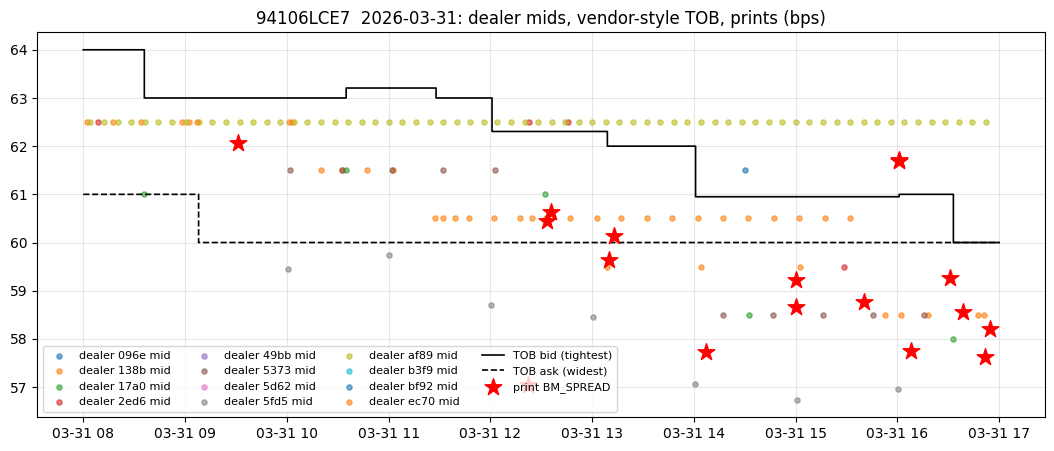

In [10]:
st_ny_day = state.ts.dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
firms_per_day = state.groupby([state.cusip, st_ny_day]).firm.nunique()
day_counts = prints[cov].groupby(["CUSIP", "DATE"]).size()
cusip, day = (day_counts[day_counts >= 8] * firms_per_day.reindex(day_counts[day_counts >= 8].index).fillna(0)).idxmax()   # busy day, many dealers
lo, hi = pd.Timestamp(day, tz="America/New_York") + pd.Timedelta("8h"), pd.Timestamp(day, tz="America/New_York") + pd.Timedelta("17h")
to_ny = lambda s: pd.to_datetime(s, utc=True).dt.tz_convert("America/New_York")

fig, ax = plt.subplots(figsize=(13, 5))
st_d = state[(state.cusip == cusip) & (to_ny(state.ts) >= lo) & (to_ny(state.ts) <= hi)]
for i, (f, g) in enumerate(st_d.groupby("firm")):
    ax.scatter(to_ny(g.ts), g.mid, s=14, alpha=.6, color=f"C{i % 10}", label=f"dealer {f[:4]} mid")
tb = tob_full[(tob_full.cusip == cusip) & (to_ny(tob_full.ts) >= lo) & (to_ny(tob_full.ts) <= hi)]
ax.step(to_ny(tb.ts), tb.bid, where="post", color="k", lw=1.2, label="TOB bid (tightest)")
ax.step(to_ny(tb.ts), tb.ask, where="post", color="k", lw=1.2, ls="--", label="TOB ask (widest)")
pr = prints[(prints.CUSIP == cusip) & (prints.DATE == day)]
ax.scatter(_to_utc(pr.EFFECTIVE_DATETIME_TS).dt.tz_convert("America/New_York"), pr.BM_SPREAD * 100, marker="*", s=160, color="red", zorder=5, label="print BM_SPREAD")
ax.set_title(f"{cusip}  {day:%Y-%m-%d}: dealer mids, vendor-style TOB, prints (bps)")
ax.legend(ncol=4, fontsize=8); ax.grid(alpha=.3); plt.show()

### 2.2 Route 2: features directly on the TOB snapshot (`tob_features_at_prints`)

As-of the last snapshot before the print time (`allow_exact_matches=False`). Five feature families, each marked with the optional columns it depends on:

| Family | Features | Needs | Idea |
|---|---|---|---|
| Freshness | `TOB_SNAP_AGE_SEC` | — | the snapshot's own delay (grid granularity) |
|  | `TOB_BID_AGE_SEC / ASK_AGE_SEC / AGE_MIN_SEC` | update times | how old each side is; a side older than `max_age` is treated as absent |
|  | `TOB_LAST_SIDE_UPDATED` | update times | which side moved last (+1 = bid): a directional hint |
| Level | `TOB_BID/ASK/MID/WIDTH`, `D_TOB_MID`, `D_TOB_SIDE` | — | moved into the model's coordinate `X − PREV_BM_SPREAD + offset`; the side follows the trade direction |
|  | `TOB_*_VS_CPP*` | CPP columns | position relative to CPP; `AGE_MIN_MINUS_CPP_AGE` says which is fresher |
|  | `TOB_CROSSED` | — | bid spread < ask spread: a stale aggressive quote sits on the TOB (about 1/3 of two-sided TOB rows in this data are crossed). A snapshot **cannot be uncrossed** (no second level is visible); it can only be flagged for the model |
| Size | `TOB_SIZE_*`, `TOB_LOG_SIDE_SIZE_OVER_QTY` | size | trade size relative to quoted size |
| Last change | `TOB_SEC_SINCE_LAST_CHANGE`, `TOB_LAST_CHANGE` | — | a per-bond cumulative "mid changed" counter on the snapshot table → every window statistic is the difference of two as-of lookups |
| Dynamics | `TOB_D_MID_{W}`, `TOB_D_WIDTH_{W}` | — | **naive difference**: TOB now minus TOB W ago. Without dealer identity this is all there is, and a change of who is on top counts as a price change |
|  | `TOB_N_CHANGES_{W}`, `TOB_UPDATE_IMBALANCE_{W}` | — | number of changes; whether the bid or the ask side is moving |
|  | `TOB_CHAINED_MID_{W}` | dealer name (rare) | only if the feed names the dealer on top: counts a change only when the same dealer holds the TOB at both ends. Not produced here |

Three windows W: since the previous print (`SINCE_PREV`), 30 minutes, 2 hours.

In [11]:
# ---- library: native TOB features at print times ----
@dataclass(frozen=True)
class SnapshotConfig:
    unit: str = "spread_bps"                              # "spread_bps" | "spread_pct" | "yield_pct" | "price"
    availability_lag: pd.Timedelta = pd.Timedelta(0)
    max_age: pd.Timedelta = pd.Timedelta("120min")       # a side (or ladder) older than this is treated as absent
    windows: tuple[tuple[str, pd.Timedelta], ...] = (("30M", pd.Timedelta("30min")), ("2H", pd.Timedelta("2h")))
    include_since_prev: bool = True
    # price -> spread needs bond analytics: (levels array, print frame) -> spread in %
    to_spread_pct: Callable[[np.ndarray, pd.DataFrame], np.ndarray] | None = None
    # print columns
    cusip_col: str = "CUSIP"
    trade_time_col: str = "EFFECTIVE_DATETIME_TS"
    prev_time_col: str = "PREV_EFFECTIVE_DATETIME_TS_x"
    trade_type_col: str = "TRADE_TYPE"
    quantity_col: str = "QUANTITY"
    prev_bm_spread_col: str = "PREV_BM_SPREAD"
    bm_offset_col: str = "D_BM_YIELD_OFFSET"
    bm_yield_col: str = "BM_YIELD"                        # yield-quoted data: spread = yield - benchmark yield
    cpp_bid_col: str = "BID_SPREAD_CPP"
    cpp_ask_col: str = "ASK_SPREAD_CPP"
    cpp_mid_col: str = "MID_SPREAD_CPP"
    cpp_time_col: str = "LASTUPDATETIME_CPP"


def _to_spread_pct(v: np.ndarray, obs: pd.DataFrame, cfg: SnapshotConfig) -> np.ndarray:
    """Quote level(s) in the native unit -> spread in %.  ``v`` is (n,) or (n, k) aligned with ``obs`` rows."""
    if cfg.unit == "spread_bps":
        return v / 100.0
    if cfg.unit == "spread_pct":
        return v
    if cfg.unit == "yield_pct":
        bm = pd.to_numeric(obs[cfg.bm_yield_col], errors="coerce").to_numpy()
        return v - (bm[:, None] if v.ndim == 2 else bm)
    if cfg.unit == "price":
        if cfg.to_spread_pct is None:
            raise ValueError("price-quoted data needs cfg.to_spread_pct (price -> yield via bond analytics, minus the benchmark yield)")
        return cfg.to_spread_pct(v, obs)
    raise ValueError(f"unknown unit {cfg.unit!r}")


def _prep_prints(prints: pd.DataFrame, cfg: SnapshotConfig) -> pd.DataFrame:
    P = pd.DataFrame(index=prints.index)
    P["cusip"] = prints[cfg.cusip_col].astype(str)
    P["_t"] = _to_utc(prints[cfg.trade_time_col]) - cfg.availability_lag
    if cfg.include_since_prev:
        if cfg.prev_time_col in prints.columns:
            P["_t_prev"] = _to_utc(prints[cfg.prev_time_col]) - cfg.availability_lag
        else:
            P["_t_prev"] = P.sort_values("_t").groupby("cusip")["_t"].shift().reindex(P.index)
    return P


def _asof(P: pd.DataFrame, t: pd.Series, table: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Last snapshot strictly before ``t`` per cusip (``table`` sorted by ts); index = P.index, columns = cols + 'snap_ts'."""
    left = pd.DataFrame({"cusip": P["cusip"].to_numpy(), "_t": t.to_numpy(), "_i": np.arange(len(P))})
    left = left.dropna(subset=["_t"]).sort_values("_t", kind="stable")
    m = pd.merge_asof(left, table[["cusip", "ts", *cols]], left_on="_t", right_on="ts", by="cusip",
                      direction="backward", allow_exact_matches=False)
    m = m.set_index("_i").reindex(range(len(P)))
    m.index = P.index
    return m[cols].assign(snap_ts=m["ts"])


def _age_sec(t: pd.Series, when: pd.Series) -> np.ndarray:
    return (t - pd.to_datetime(when, utc=True)).dt.total_seconds().to_numpy()


def _changed(x: pd.DataFrame | pd.Series, groups: pd.Series) -> pd.Series:
    """Row differs from the previous row of the same cusip (NaN-safe; first row of a cusip is not a change)."""
    prev = x.groupby(groups).shift()
    diff = x.ne(prev) & ~(x.isna() & prev.isna())
    if isinstance(diff, pd.DataFrame):
        diff = diff.any(axis=1)
    return diff & (groups.groupby(groups).cumcount() > 0)


def _add_tob_counters(T: pd.DataFrame) -> pd.DataFrame:
    """Per-cusip cumulative counters on the TOB table so window statistics become as-of differences."""
    g = T["cusip"]
    T["_mid"] = (T["bid"] + T["ask"]) / 2
    T["_n_mid_chg"] = _changed(T["_mid"], g).groupby(g).cumsum()
    T["_n_bid_chg"] = _changed(T["bid"], g).groupby(g).cumsum()
    T["_n_ask_chg"] = _changed(T["ask"], g).groupby(g).cumsum()
    prev_mid = T["_mid"].groupby(g).shift()
    moved = (T["_mid"] - prev_mid).abs().gt(1e-9)
    T["_last_chg_ts"] = T["ts"].where(moved).groupby(g).ffill()
    T["_last_chg_to"] = T["_mid"].where(moved).groupby(g).ffill()      # mid after the last change ...
    T["_last_chg_from"] = prev_mid.where(moved).groupby(g).ffill()     # ... and before it (units converted later)
    return T


def _cpp(prints, cfg):
    cb = pd.to_numeric(prints[cfg.cpp_bid_col], errors="coerce").to_numpy()
    ca = pd.to_numeric(prints[cfg.cpp_ask_col], errors="coerce").to_numpy()
    cm = pd.to_numeric(prints[cfg.cpp_mid_col], errors="coerce").to_numpy() if cfg.cpp_mid_col in prints.columns else (cb + ca) / 2
    return cb, ca, cm


def tob_features_at_prints(prints: pd.DataFrame, tob: pd.DataFrame, cfg: SnapshotConfig = SnapshotConfig(), *,
                           prefix: str = "TOB", bid_col="bid", ask_col="ask", bid_size_col="bid_size", ask_size_col="ask_size",
                           bid_firm_col="bid_firm", ask_firm_col="ask_firm", bid_time_col="bid_time", ask_time_col="ask_time",
                           ts_col="ts", cusip_col="cusip") -> pd.DataFrame:
    """Point-in-time features from a TOB snapshot table; returns ``prints`` with ``{prefix}_*`` columns.

    Uses the last snapshot strictly before the (lagged) print time.  Size / firm / update-time
    columns are optional: a missing column drops the features that need it.
    """
    T = tob.rename(columns={ts_col: "ts", cusip_col: "cusip", bid_col: "bid", ask_col: "ask", bid_size_col: "bid_size",
                            ask_size_col: "ask_size", bid_firm_col: "bid_firm", ask_firm_col: "ask_firm",
                            bid_time_col: "bid_time", ask_time_col: "ask_time"}).copy()
    T["cusip"] = T["cusip"].astype(str)
    T["ts"] = pd.to_datetime(T["ts"], utc=True)
    T = _add_tob_counters(T.sort_values(["cusip", "ts"], kind="stable").reset_index(drop=True))
    T = T.sort_values("ts", kind="stable")                      # merge_asof needs the right key globally sorted
    has_size, has_firm, has_time = "bid_size" in T.columns, "bid_firm" in T.columns, "bid_time" in T.columns
    conv = lambda a: _to_spread_pct(np.asarray(a, dtype="float64"), prints, cfg)

    P = _prep_prints(prints, cfg)
    tt = prints[cfg.trade_type_col].astype(str).to_numpy() if cfg.trade_type_col in prints.columns else np.full(len(prints), "D")
    cols = ["bid", "ask", "_n_mid_chg", "_n_bid_chg", "_n_ask_chg", "_last_chg_ts", "_last_chg_to", "_last_chg_from"]
    cols += (["bid_size", "ask_size"] if has_size else []) + (["bid_firm", "ask_firm"] if has_firm else []) + (["bid_time", "ask_time"] if has_time else [])
    now = _asof(P, P["_t"], T, cols)
    out: dict[str, np.ndarray] = {}
    pfx = prefix

    # ---- staleness: the snapshot's own delay, plus each side's last update if the feed has it ----
    snap_age = _age_sec(P["_t"], now["snap_ts"])
    out[f"{pfx}_SNAP_AGE_SEC"] = snap_age
    age_b, age_a = (_age_sec(P["_t"], now["bid_time"]), _age_sec(P["_t"], now["ask_time"])) if has_time else (snap_age, snap_age)
    max_age = cfg.max_age.total_seconds()
    bid = np.where(age_b <= max_age, now["bid"].to_numpy(dtype="float64"), np.nan)
    ask = np.where(age_a <= max_age, now["ask"].to_numpy(dtype="float64"), np.nan)
    if has_time:
        out[f"{pfx}_BID_AGE_SEC"] = np.where(np.isfinite(bid), age_b, np.nan)
        out[f"{pfx}_ASK_AGE_SEC"] = np.where(np.isfinite(ask), age_a, np.nan)
        out[f"{pfx}_AGE_MIN_SEC"] = np.fmin(out[f"{pfx}_BID_AGE_SEC"], out[f"{pfx}_ASK_AGE_SEC"])
        out[f"{pfx}_LAST_SIDE_UPDATED"] = np.where(np.isfinite(bid) & np.isfinite(ask), np.sign(age_a - age_b), np.nan)  # +1 bid fresher
    else:
        out[f"{pfx}_AGE_MIN_SEC"] = snap_age

    # ---- levels in model units ----
    bid_pct, ask_pct = conv(bid), conv(ask)
    mid_pct, width = (bid_pct + ask_pct) / 2, bid_pct - ask_pct
    side_pct = _by_side(tt, bid_pct, ask_pct, mid_pct)
    out[f"{pfx}_BID"], out[f"{pfx}_ASK"], out[f"{pfx}_MID"], out[f"{pfx}_WIDTH"] = bid_pct, ask_pct, mid_pct, width
    out[f"{pfx}_TWO_SIDED"] = (np.isfinite(bid) & np.isfinite(ask)).astype("float64")
    out[f"{pfx}_CROSSED"] = np.where(np.isfinite(width), (width < 0).astype("float64"), np.nan)   # bid tighter than ask
    if cfg.prev_bm_spread_col in prints.columns:
        out[f"D_{pfx}_MID"] = _model_coord(mid_pct, prints, cfg)
        out[f"D_{pfx}_SIDE"] = _model_coord(side_pct, prints, cfg)
    if cfg.cpp_bid_col in prints.columns and cfg.cpp_ask_col in prints.columns:
        cb, ca, cm = _cpp(prints, cfg)
        out[f"{pfx}_MID_VS_CPP"] = mid_pct - cm
        out[f"{pfx}_SIDE_VS_CPP_SIDE"] = side_pct - _by_side(tt, cb, ca, cm)
        out[f"{pfx}_WIDTH_VS_CPP"] = width - np.abs(cb - ca)
        if cfg.cpp_time_col in prints.columns:
            out[f"{pfx}_AGE_MIN_MINUS_CPP_AGE_SEC"] = out[f"{pfx}_AGE_MIN_SEC"] - _age_sec(P["_t"], _to_utc(prints[cfg.cpp_time_col]))

    # ---- size ----
    if has_size:
        sb = np.where(np.isfinite(bid), now["bid_size"].to_numpy(dtype="float64"), np.nan)
        sa = np.where(np.isfinite(ask), now["ask_size"].to_numpy(dtype="float64"), np.nan)
        tb, ta = np.nan_to_num(sb), np.nan_to_num(sa)
        out[f"{pfx}_SIZE_BID_MM"], out[f"{pfx}_SIZE_ASK_MM"] = sb, sa
        with np.errstate(all="ignore"):
            out[f"{pfx}_SIZE_IMBALANCE"] = np.where(tb + ta > 0, (tb - ta) / (tb + ta), np.nan)
            if cfg.quantity_col in prints.columns:
                qty_mm = pd.to_numeric(prints[cfg.quantity_col], errors="coerce").to_numpy() / 1e6
                side_size = _by_side(tt, tb, ta, tb + ta)
                out[f"{pfx}_LOG_SIDE_SIZE_OVER_QTY"] = np.where(side_size > 0, np.log(side_size / qty_mm), np.nan)

    # ---- last TOB change ----
    out[f"{pfx}_SEC_SINCE_LAST_CHANGE"] = _age_sec(P["_t"], now["_last_chg_ts"])
    out[f"{pfx}_LAST_CHANGE"] = conv(now["_last_chg_to"]) - conv(now["_last_chg_from"])

    # ---- dynamics between two snapshots ----
    def dyn(then: pd.DataFrame, label: str):
        b_then, a_then = conv(then["bid"]), conv(then["ask"])
        out[f"{pfx}_D_MID_{label}"] = mid_pct - (b_then + a_then) / 2          # naive: whoever is on top now vs then
        out[f"{pfx}_D_WIDTH_{label}"] = width - (b_then - a_then)
        if has_firm:                                                            # same dealer on top at both ends
            d_b, d_a = bid_pct - b_then, ask_pct - a_then
            same_b = (now["bid_firm"].to_numpy() == then["bid_firm"].to_numpy()) & np.isfinite(d_b)
            same_a = (now["ask_firm"].to_numpy() == then["ask_firm"].to_numpy()) & np.isfinite(d_a)
            cb_, ca_ = np.where(same_b, d_b, np.nan), np.where(same_a, d_a, np.nan)
            with np.errstate(all="ignore"):
                chained = np.nanmean(np.stack([cb_, ca_]), axis=0)
            out[f"{pfx}_CHAINED_MID_{label}"] = chained
            out[f"{pfx}_CHAINED_SIDE_{label}"] = _by_side(tt, cb_, ca_, chained)
        n_mid = now["_n_mid_chg"].to_numpy(dtype="float64") - then["_n_mid_chg"].to_numpy(dtype="float64")
        n_b = now["_n_bid_chg"].to_numpy(dtype="float64") - then["_n_bid_chg"].to_numpy(dtype="float64")
        n_a = now["_n_ask_chg"].to_numpy(dtype="float64") - then["_n_ask_chg"].to_numpy(dtype="float64")
        out[f"{pfx}_N_CHANGES_{label}"] = n_mid
        with np.errstate(all="ignore"):
            out[f"{pfx}_UPDATE_IMBALANCE_{label}"] = np.where(n_b + n_a > 0, (n_b - n_a) / (n_b + n_a), np.nan)

    if cfg.include_since_prev and "_t_prev" in P.columns:
        dyn(_asof(P, P["_t_prev"], T, cols), "SINCE_PREV")
    for label, td in cfg.windows:
        dyn(_asof(P, P["_t"] - td, T, cols), label)
    return pd.concat([prints, pd.DataFrame(out, index=prints.index)], axis=1)


def snapshot_feature_names(columns, prefix: str) -> list[str]:
    return [c for c in columns if c.startswith((f"{prefix}_", f"D_{prefix}_"))]

In [12]:
cfg_snap = SnapshotConfig(unit="spread_bps", max_age=pd.Timedelta("120min"))
tobF = tob_features_at_prints(prints, tob_full, cfg_snap)           # levels + update times + size
tobM = tob_features_at_prints(prints, tob_min, cfg_snap)            # levels + update times
tobN = tob_features_at_prints(prints, tob_min.drop(columns=["bid_time", "ask_time"]), cfg_snap)   # levels only
fF, fM, fN = (snapshot_feature_names(x.columns, "TOB") for x in (tobF, tobM, tobN))
print(f"features: with size {len(fF)}, without size {len(fM)}, levels only {len(fN)}")
print("dropped without size:", sorted(set(fF) - set(fM)))
print("dropped without update times:", sorted(set(fM) - set(fN)))
cov_tab = pd.DataFrame({"non_null_on_covered": tobF.loc[cov, fF].notna().mean().round(3), "median": tobF.loc[cov, fF].median().round(4)})
cov_tab

features: with size 35, without size 31, levels only 28
dropped without size: ['TOB_LOG_SIDE_SIZE_OVER_QTY', 'TOB_SIZE_ASK_MM', 'TOB_SIZE_BID_MM', 'TOB_SIZE_IMBALANCE']
dropped without update times: ['TOB_ASK_AGE_SEC', 'TOB_BID_AGE_SEC', 'TOB_LAST_SIDE_UPDATED']


,non_null_on_covered,median
TOB_SNAP_AGE_SEC,0.997,28.0000
TOB_BID_AGE_SEC,0.638,1771.0000
TOB_ASK_AGE_SEC,0.616,1771.0000
TOB_AGE_MIN_SEC,0.834,1221.0000
TOB_LAST_SIDE_UPDATED,0.420,0.0000
TOB_BID,0.638,0.6700
TOB_ASK,0.616,0.7100
TOB_MID,0.420,0.6275
TOB_WIDTH,0.420,0.0157
TOB_TWO_SIDED,1.000,0.0000


Without update times, freshness collapses to the grid delay and the `max_age` gate stops working — a 9 am quote is still treated as the current level at 3 pm. In the TOB shape this is **the single column most worth asking the vendor for**.

### 2.3 Route 1: TOB → events → dealer engine

`quotes_from_tob_snapshots` turns each snapshot's bid / ask into one event each (stamped with its own update time; consecutive identical snapshots collapse into one), then runs exactly the same `build_dealer_state → build_bcq_features` as shape A. With no dealer names both sides merge into a single pseudo-dealer `TOB`, so that a mid / width exists (a feed that does name the dealer on top would use that name instead).

What degrades: `BCQ_N_DEALERS ≤ 1`, all dispersion features (`BCQ_MID_MAD`, `BCQ_BID_RANGE`, …) are NaN, uncrossing has no second level to fall back on, and the "chained" moves are the TOB's own changes — a change of dealer on top is counted as a re-price. The upside is that feature names match shape A, so the model code does not change.

In [13]:
# ---- library: TOB snapshots -> canonical events (route 1) ----
def _event_frame(cusip, firm, ts, side, spread, quantity) -> pd.DataFrame:
    return pd.DataFrame({"cusip": cusip.astype(str), "firm": firm, "ts": ts, "side": side, "price_type": "spread",
                         "spread": pd.to_numeric(spread, errors="coerce"), "price": np.nan,
                         "quantity": pd.to_numeric(quantity, errors="coerce") if quantity is not None else np.nan}).dropna(subset=["spread"])


def _collapse_repeats(parts: list[pd.DataFrame]) -> pd.DataFrame:
    """Concatenate snapshot-derived events and drop rows identical to the dealer/side's previous row (NaN-safe)."""
    out = pd.concat(parts, ignore_index=True).sort_values(["cusip", "firm", "side", "ts"], kind="stable")
    vals = out[["spread", "quantity"]].fillna(-1e18)
    prev = vals.groupby([out["cusip"], out["firm"], out["side"]]).shift()
    same = vals.eq(prev).all(axis=1) & prev.notna().all(axis=1)
    return out[~same].reset_index(drop=True)[CANONICAL_COLS]


def quotes_from_tob_snapshots(
    tob: pd.DataFrame,
    *,
    ts_col="ts_seq",
    cusip_col="cusip",
    bid_col="Sprd_Bid_Val",
    ask_col="Sprd_Ask_Val",
    bid_size_col="Sprd_Bid_Sz",
    ask_size_col="Sprd_Ask_Sz",
    bid_firm_col="Sprd_Bid_Firm",
    ask_firm_col="Sprd_Ask_Firm",
    bid_time_col="Time_Sprd_Bid_UTC",
    ask_time_col="Time_Sprd_Ask_UTC",
) -> pd.DataFrame:
    """Top-of-book snapshots on a time grid -> canonical events.

    The snapshot time is replaced by the quote's own timestamp when available so
    staleness is measured correctly.  With TOB only, depth / breadth / dispersion
    features degenerate (one dealer per side); level, freshness and chained moves
    remain meaningful.  Without firm columns both sides become one pseudo-dealer
    ``TOB`` so that a mid / width exists.
    """
    snap_ts = pd.to_datetime(tob[ts_col], utc=True)
    parts = []
    for side, vcol, scol, fcol, tcol in (("bid", bid_col, bid_size_col, bid_firm_col, bid_time_col),
                                         ("ask", ask_col, ask_size_col, ask_firm_col, ask_time_col)):
        ev_ts = snap_ts
        if tcol in tob.columns:
            if pd.api.types.is_datetime64_any_dtype(tob[tcol]):        # full timestamps
                t = pd.to_datetime(tob[tcol], utc=True)
            else:                                                        # time-of-day strings, same day as the snapshot
                t = pd.to_datetime(snap_ts.dt.strftime("%Y-%m-%d") + " " + tob[tcol].astype(str), utc=True, errors="coerce")
                t = t.where(t <= snap_ts, t - pd.Timedelta(days=1))
            ev_ts = t.fillna(snap_ts)
        firm = tob[fcol].astype(str) if fcol in tob.columns else "TOB"
        parts.append(_event_frame(tob[cusip_col], firm, ev_ts, side, tob[vcol], tob[scol] if scol in tob.columns else None))
    return _collapse_repeats(parts)

In [14]:
tob_cols = dict(ts_col="ts", bid_col="bid", ask_col="ask", bid_size_col="bid_size", ask_size_col="ask_size", bid_time_col="bid_time", ask_time_col="ask_time")
ev_tob = quotes_from_tob_snapshots(tob_full, **tob_cols)
print(f"{len(tob_full):,} TOB rows -> {len(ev_tob):,} events from pseudo-dealer {ev_tob.firm.unique().tolist()} (raw stream had {len(quotes):,})")
tobA = build_bcq_features(prints, build_dealer_state(ev_tob), cfg_raw)
pd.DataFrame({"raw stream": raw.loc[cov, "BCQ_N_DEALERS"].describe(), "TOB -> events": tobA.loc[cov, "BCQ_N_DEALERS"].describe()}).round(2).T

2,645,393 TOB rows -> 35,138 events from pseudo-dealer ['TOB'] (raw stream had 759,246)


,count,mean,std,min,25%,50%,75%,max
raw stream,11408.0,3.99,2.49,0.0,2.0,4.0,6.0,13.0
TOB -> events,11408.0,0.61,0.49,0.0,0.0,1.0,1.0,1.0


## 3. Shape C: 5-level ladder snapshots

### 3.1 Converting BondCliQ into a ladder

Same grid; per side take the 5 best dealers among live quotes, **one dealer per level**, ordered best to worst (bid: spread ascending; ask: descending). Each level may carry size. The ladder has only two timestamps: the oldest and the newest update among all levels — which means **you cannot tell which level is the stale one**. Dealer names per level are not emitted (`with_firm=False`): this is how ladders normally arrive, and the case the rest of the section is about. Levels are ranks, not dealers.

In [15]:
# ---- library: dealer state -> ladder snapshots ----
def dealer_state_to_ladder(state: pd.DataFrame, grid: pd.DataFrame, *, levels: int = 5,
                           live_for: pd.Timedelta = pd.Timedelta("10h"), with_size: bool = True,
                           with_firm: bool = False) -> pd.DataFrame:
    """Level 1..N ladder snapshots (one dealer per level, best first) with the ladder's oldest/newest update time."""
    parts = []
    for ch, M, firms in _live_matrices(state, grid, live_for):
        bv, bs, bf, bt = _pick(M, "bid", firms, levels)
        av, as_, af, at = _pick(M, "ask", firms, levels)
        out = pd.DataFrame({"cusip": ch["_cusip"].to_numpy(), "ts": ch["_t"].to_numpy()})
        for i in range(levels):
            out[f"bid_{i + 1}"], out[f"ask_{i + 1}"] = bv[:, i], av[:, i]
        if with_size:
            for i in range(levels):
                out[f"bid_size_{i + 1}"], out[f"ask_size_{i + 1}"] = bs[:, i], as_[:, i]
        if with_firm:
            for i in range(levels):
                out[f"bid_firm_{i + 1}"], out[f"ask_firm_{i + 1}"] = bf[:, i], af[:, i]
        all_t = np.concatenate([bt, at], axis=1)
        with np.errstate(all="ignore"):
            out["oldest_update"] = _epoch_to_ts(np.nanmin(all_t, axis=1))
            out["newest_update"] = _epoch_to_ts(np.nanmax(all_t, axis=1))
        parts.append(out[np.isfinite(bv[:, 0]) | np.isfinite(av[:, 0])])
    return pd.concat(parts, ignore_index=True).sort_values(["cusip", "ts"], kind="stable").reset_index(drop=True)

In [16]:
t0 = time.time()
lad_full = dealer_state_to_ladder(state, grid, levels=5, with_size=True, with_firm=False)     # levels + size + oldest/newest
lad_nosize = lad_full.drop(columns=[c for c in lad_full.columns if "_size_" in c])            # levels + oldest/newest only
print(f"ladder rows {len(lad_full):,} in {time.time() - t0:.0f}s")
depth = lad_full[[f"bid_{i}" for i in range(1, 6)]].notna().sum(axis=1)
print("bid levels filled:", depth.value_counts(normalize=True).sort_index().round(3).to_dict())
lad_full.head(3).T

ladder rows 2,645,393 in 23s
bid levels filled: {0: 0.009, 1: 0.091, 2: 0.127, 3: 0.131, 4: 0.126, 5: 0.515}


,0,1,2
cusip,032095AH4,032095AH4,032095AH4
ts,2026-03-02 13:00:00+00:00,2026-03-02 13:01:00+00:00,2026-03-02 13:02:00+00:00
bid_1,50.0,45.0,45.0
ask_1,40.0,40.0,40.0
bid_2,NaN,50.0,50.0
ask_2,NaN,40.0,40.0
bid_3,NaN,NaN,NaN
ask_3,NaN,NaN,NaN
bid_4,NaN,NaN,NaN
ask_4,NaN,NaN,NaN


### 3.2 Route 2: native ladder features (`ladder_features_at_prints`)

Level 1 is the TOB, so every feature of §2.2 reappears under the `LAD_L1_*` prefix (the ladder's newest update time stands in for the per-side times). Ladder-specific families:

| Family | Features | Idea |
|---|---|---|
| Depth | `LAD_N_BID_LEVELS / N_ASK_LEVELS / DEPTH_IMBALANCE` | how many levels, which side is crowded |
| Dispersion | `LAD_BID_MED / ASK_MED / MID_MED / WIDTH_MED`, `LAD_BID_RANGE / ASK_RANGE` | the median over levels is far more stable than L1 (L1 is often a stale aggressive quote); level spacing = dealer disagreement. `D_LAD_MID_MED` is the closest thing to `D_BCQ_MID` in this shape |
| CPP position | `LAD_SHARE_BID_WIDER_THAN_CPP`, `LAD_SHARE_ASK_TIGHTER_THAN_CPP`, `LAD_CPP_MID_PCTL` | where the composite ranks inside the ladder |
| Size | `LAD_SIZE_*`, `LAD_VWAP_BID / ASK`, `LAD_VWAP_MID_MINUS_MID_MED` | is size stacked on the wide or on the tight side |
| Freshness | `LAD_OLDEST_AGE_SEC / NEWEST_AGE_SEC` | only whole-ladder gating (newest too old → discard the ladder); **no per-level uncrossing** |
| Dynamics | `LAD_D_MID_MED_{W}`, `LAD_D_LEVEL_MED_{W}`, `LAD_SHARE_LEVELS_WIDER_{W}`, `LAD_N_LADDER_CHANGES_{W}` | all **composition-noisy**: level k now and level k W ago may be two different dealers. Without dealer names there is no chained move — the best you can do is the median of per-rank changes, which at least averages the rank churn |

In [17]:
# ---- library: native ladder features at print times ----
def ladder_features_at_prints(prints: pd.DataFrame, ladder: pd.DataFrame, cfg: SnapshotConfig = SnapshotConfig(), *,
                              levels: int = 5, prefix: str = "LAD", bid_fmt="bid_{i}", ask_fmt="ask_{i}",
                              bid_size_fmt="bid_size_{i}", ask_size_fmt="ask_size_{i}", bid_firm_fmt="bid_firm_{i}",
                              ask_firm_fmt="ask_firm_{i}", oldest_col="oldest_update", newest_col="newest_update",
                              ts_col="ts", cusip_col="cusip") -> pd.DataFrame:
    """Point-in-time features from a level-1..N ladder; returns ``prints`` with ``{prefix}_*`` columns.

    Level 1 is the TOB: all ``tob_features_at_prints`` features appear as ``{prefix}_L1_*`` (the
    ladder's newest update time is the freshness proxy for both sides).  Then depth, dispersion,
    size weighting and ladder-level dynamics across levels 1..N.
    """
    L = ladder.rename(columns={ts_col: "ts", cusip_col: "cusip"}).copy()
    L["cusip"] = L["cusip"].astype(str)
    L["ts"] = pd.to_datetime(L["ts"], utc=True)
    L = L.sort_values(["cusip", "ts"], kind="stable").reset_index(drop=True)
    present = lambda fmt: [fmt.format(i=i) for i in range(1, levels + 1) if fmt.format(i=i) in L.columns]
    bcols, acols, bscols, ascols = present(bid_fmt), present(ask_fmt), present(bid_size_fmt), present(ask_size_fmt)
    has_size = len(bscols) == len(bcols) > 0 and len(ascols) == len(acols)
    has_time = oldest_col in L.columns and newest_col in L.columns
    has_firm = bid_firm_fmt.format(i=1) in L.columns and ask_firm_fmt.format(i=1) in L.columns

    # level-1 block through the TOB builder
    l1 = L[["cusip", "ts", bcols[0], acols[0]]].rename(columns={bcols[0]: "bid", acols[0]: "ask"})
    if has_size:
        l1 = l1.assign(bid_size=L[bscols[0]], ask_size=L[ascols[0]])
    if has_firm:
        l1 = l1.assign(bid_firm=L[bid_firm_fmt.format(i=1)], ask_firm=L[ask_firm_fmt.format(i=1)])
    if has_time:
        l1 = l1.assign(bid_time=L[newest_col], ask_time=L[newest_col])
    out_df = tob_features_at_prints(prints, l1, cfg, prefix=f"{prefix}_L1")

    # whole-ladder statistics
    P = _prep_prints(prints, cfg)
    tt = prints[cfg.trade_type_col].astype(str).to_numpy() if cfg.trade_type_col in prints.columns else np.full(len(prints), "D")
    conv = lambda a: _to_spread_pct(np.asarray(a, dtype="float64"), prints, cfg)
    L["_mid_med"] = (L[bcols].median(axis=1) + L[acols].median(axis=1)) / 2
    L["_n_any_chg"] = _changed(L[bcols + acols], L["cusip"]).groupby(L["cusip"]).cumsum()
    cols = bcols + acols + bscols + ascols + ["_mid_med", "_n_any_chg"] + ([oldest_col, newest_col] if has_time else [])
    L = L.sort_values("ts", kind="stable")
    now = _asof(P, P["_t"], L, cols)
    out: dict[str, np.ndarray] = {}
    pfx = prefix

    fresh = np.ones(len(P), dtype=bool)
    if has_time:
        out[f"{pfx}_OLDEST_AGE_SEC"] = _age_sec(P["_t"], now[oldest_col])
        out[f"{pfx}_NEWEST_AGE_SEC"] = _age_sec(P["_t"], now[newest_col])
        fresh = out[f"{pfx}_NEWEST_AGE_SEC"] <= cfg.max_age.total_seconds()
    bids = np.where(fresh[:, None], now[bcols].to_numpy(dtype="float64"), np.nan)
    asks = np.where(fresh[:, None], now[acols].to_numpy(dtype="float64"), np.nan)
    bids_pct, asks_pct = conv(bids), conv(asks)
    nb, na = np.isfinite(bids).sum(axis=1).astype("float64"), np.isfinite(asks).sum(axis=1).astype("float64")

    # ---- depth / dispersion ----
    out[f"{pfx}_N_BID_LEVELS"], out[f"{pfx}_N_ASK_LEVELS"] = nb, na
    with np.errstate(all="ignore"):
        out[f"{pfx}_DEPTH_IMBALANCE"] = np.where(nb + na > 0, (nb - na) / (nb + na), np.nan)
        bid_med, ask_med = _nanmedian_rows(bids_pct), _nanmedian_rows(asks_pct)
        out[f"{pfx}_BID_RANGE"] = np.nanmax(bids_pct, axis=1) - np.nanmin(bids_pct, axis=1)
        out[f"{pfx}_ASK_RANGE"] = np.nanmax(asks_pct, axis=1) - np.nanmin(asks_pct, axis=1)
    mid_med = (bid_med + ask_med) / 2
    side_med = _by_side(tt, bid_med, ask_med, mid_med)
    out[f"{pfx}_BID_MED"], out[f"{pfx}_ASK_MED"], out[f"{pfx}_MID_MED"] = bid_med, ask_med, mid_med
    out[f"{pfx}_WIDTH_MED"] = bid_med - ask_med
    if cfg.prev_bm_spread_col in prints.columns:
        out[f"D_{pfx}_MID_MED"] = _model_coord(mid_med, prints, cfg)
        out[f"D_{pfx}_SIDE_MED"] = _model_coord(side_med, prints, cfg)
    if cfg.cpp_bid_col in prints.columns and cfg.cpp_ask_col in prints.columns:
        cb, ca, cm = _cpp(prints, cfg)
        out[f"{pfx}_MID_MED_VS_CPP"] = mid_med - cm
        with np.errstate(all="ignore"):
            out[f"{pfx}_SHARE_BID_WIDER_THAN_CPP"] = np.where(nb > 0, np.nansum(bids_pct > cb[:, None], axis=1) / nb, np.nan)
            out[f"{pfx}_SHARE_ASK_TIGHTER_THAN_CPP"] = np.where(na > 0, np.nansum(asks_pct < ca[:, None], axis=1) / na, np.nan)
            below = np.nansum(bids_pct < cm[:, None], axis=1) + np.nansum(asks_pct < cm[:, None], axis=1)
            out[f"{pfx}_CPP_MID_PCTL"] = np.where(nb + na > 0, below / (nb + na), np.nan)

    # ---- size weighting ----
    if has_size:
        sb = np.where(np.isfinite(bids), now[bscols].to_numpy(dtype="float64"), np.nan)
        sa = np.where(np.isfinite(asks), now[ascols].to_numpy(dtype="float64"), np.nan)
        tb, ta = np.nansum(sb, axis=1), np.nansum(sa, axis=1)
        out[f"{pfx}_SIZE_BID_MM"], out[f"{pfx}_SIZE_ASK_MM"] = tb, ta
        with np.errstate(all="ignore"):
            out[f"{pfx}_SIZE_IMBALANCE"] = np.where(tb + ta > 0, (tb - ta) / (tb + ta), np.nan)
            vb = np.nansum(bids_pct * sb, axis=1) / np.where(tb > 0, tb, np.nan)
            va = np.nansum(asks_pct * sa, axis=1) / np.where(ta > 0, ta, np.nan)
        out[f"{pfx}_VWAP_BID"], out[f"{pfx}_VWAP_ASK"] = vb, va
        out[f"{pfx}_VWAP_MID_MINUS_MID_MED"] = (vb + va) / 2 - mid_med       # size sits on the wide or the tight side?

    # ---- dynamics: a level is a rank, not a dealer, so all of these are composition-noisy ----
    def dyn(then: pd.DataFrame, label: str):
        out[f"{pfx}_D_MID_MED_{label}"] = mid_med - conv(then["_mid_med"])
        out[f"{pfx}_N_LADDER_CHANGES_{label}"] = now["_n_any_chg"].to_numpy(dtype="float64") - then["_n_any_chg"].to_numpy(dtype="float64")
        d = np.concatenate([bids_pct - conv(then[bcols]), asks_pct - conv(then[acols])], axis=1)
        k = np.isfinite(d).sum(axis=1)
        out[f"{pfx}_D_LEVEL_MED_{label}"] = _nanmedian_rows(d)
        with np.errstate(all="ignore"):
            out[f"{pfx}_SHARE_LEVELS_WIDER_{label}"] = np.where(k > 0, (d > 0).sum(axis=1) / np.maximum(k, 1), np.nan)

    if cfg.include_since_prev and "_t_prev" in P.columns:
        dyn(_asof(P, P["_t_prev"], L, cols), "SINCE_PREV")
    for label, td in cfg.windows:
        dyn(_asof(P, P["_t"] - td, L, cols), label)
    return pd.concat([out_df, pd.DataFrame(out, index=prints.index)], axis=1)

In [18]:
ladF = ladder_features_at_prints(prints, lad_full, cfg_snap)       # levels + size + oldest/newest
ladS = ladder_features_at_prints(prints, lad_nosize, cfg_snap)     # levels + oldest/newest
lF = [c for c in snapshot_feature_names(ladF.columns, "LAD") if not c.startswith(("LAD_L1_", "D_LAD_L1_"))]
lS = [c for c in snapshot_feature_names(ladS.columns, "LAD") if not c.startswith(("LAD_L1_", "D_LAD_L1_"))]
print(f"ladder-only features: with size {len(lF)}, without {len(lS)}; plus {len(fF)} L1 (=TOB) features")
pd.DataFrame({"non_null_on_covered": ladF.loc[cov, lF].notna().mean().round(3), "median": ladF.loc[cov, lF].median().round(4)})

ladder-only features: with size 35, without 29; plus 35 L1 (=TOB) features


,non_null_on_covered,median
LAD_OLDEST_AGE_SEC,0.997,14940.0000
LAD_NEWEST_AGE_SEC,0.997,384.5000
LAD_N_BID_LEVELS,1.000,5.0000
LAD_N_ASK_LEVELS,1.000,5.0000
LAD_DEPTH_IMBALANCE,0.925,0.0000
LAD_BID_RANGE,0.924,0.0400
LAD_ASK_RANGE,0.921,0.0400
LAD_BID_MED,0.924,0.7500
LAD_ASK_MED,0.921,0.7100
LAD_MID_MED,0.920,0.7350


### 3.3 Route 1: ladder → events, and what rank-based dynamics lose

`quotes_from_ladder_snapshots` pairs the k-th bid and the k-th ask into pseudo-dealer `L{k}` (with dealer names each level would be that dealer's event instead). A pseudo-dealer's chained move measures "how much the k-th ranked price changed", not "how much some dealer re-priced". The table compares several versions of "mid change since the previous print" — correlation with the target `D_BM_SPREAD`, and with the CPP residual (`D_BM_SPREAD − D_CPP_BM_SPREAD`, the part CPP does not explain). The raw stream's same-dealer chained change is the reference; one extra row shows what a ladder *with* dealer names would recover (rare in practice, included only to size the loss).

In [19]:
# ---- library: ladder snapshots -> canonical events (route 1) ----
def quotes_from_ladder_snapshots(
    ladder: pd.DataFrame,
    *,
    ts_col="ts",
    cusip_col="cusip",
    levels: int = 5,
    bid_val_fmt="bid_spread_{i}",
    ask_val_fmt="ask_spread_{i}",
    bid_size_fmt="bid_size_{i}",
    ask_size_fmt="ask_size_{i}",
    bid_firm_fmt="bid_firm_{i}",
    ask_firm_fmt="ask_firm_{i}",
) -> pd.DataFrame:
    """Level-1..N ladder snapshots -> canonical events.

    With firm identifiers each level is that dealer's quote; without them the k-th
    bid and k-th ask are paired into pseudo-dealer ``L{k}`` (depth features and a
    per-level mid survive, chained moves become per-rank rather than per-dealer).
    """
    snap_ts = pd.to_datetime(ladder[ts_col], utc=True)
    parts = []
    for i in range(1, levels + 1):
        for side, vf, sf, ff in (("bid", bid_val_fmt, bid_size_fmt, bid_firm_fmt), ("ask", ask_val_fmt, ask_size_fmt, ask_firm_fmt)):
            vcol, scol, fcol = vf.format(i=i), sf.format(i=i), ff.format(i=i)
            if vcol not in ladder.columns:
                continue
            firm = ladder[fcol].astype(str) if fcol in ladder.columns else f"L{i}"
            parts.append(_event_frame(ladder[cusip_col], firm, snap_ts, side, ladder[vcol], ladder[scol] if scol in ladder.columns else None))
    return _collapse_repeats(parts)

In [20]:
lad_cols = dict(ts_col="ts", bid_val_fmt="bid_{i}", ask_val_fmt="ask_{i}", bid_size_fmt="bid_size_{i}", ask_size_fmt="ask_size_{i}",
                bid_firm_fmt="bid_firm_{i}", ask_firm_fmt="ask_firm_{i}")
ladA = build_bcq_features(prints, build_dealer_state(quotes_from_ladder_snapshots(lad_full, **lad_cols)), cfg_raw)   # L{k} pseudo-dealers
# reference only: the same ladder if the feed did name the dealer on each level (rare)
lad_named = dealer_state_to_ladder(state, grid, levels=5, with_size=True, with_firm=True)
ladA_named = build_bcq_features(prints, build_dealer_state(quotes_from_ladder_snapshots(lad_named, **lad_cols)), cfg_raw)

resid = prints["D_BM_SPREAD"] - prints["D_CPP_BM_SPREAD"]
cands = {
    "A raw: BCQ_CHAINED_MID_SINCE_PREV (same dealer)": raw["BCQ_CHAINED_MID_SINCE_PREV"],
    "C ladder -> events: BCQ_CHAINED_MID_SINCE_PREV (rank k pseudo-dealer)": ladA["BCQ_CHAINED_MID_SINCE_PREV"],
    "C ladder native: LAD_D_LEVEL_MED_SINCE_PREV (median of per-rank changes)": ladF["LAD_D_LEVEL_MED_SINCE_PREV"],
    "C ladder native: LAD_D_MID_MED_SINCE_PREV (difference of level medians)": ladF["LAD_D_MID_MED_SINCE_PREV"],
    "B TOB native: TOB_D_MID_SINCE_PREV (naive TOB difference)": tobF["TOB_D_MID_SINCE_PREV"],
    "(reference, rare) C ladder with dealer names -> events: BCQ_CHAINED_MID_SINCE_PREV": ladA_named["BCQ_CHAINED_MID_SINCE_PREV"],
}
rows = []
for k, v in cands.items():
    m = cov & v.notna() & (v != 0)
    rows.append(dict(feature=k, n_nonzero=int(m.sum()), corr_target=np.corrcoef(v[m], prints.loc[m, "D_BM_SPREAD"])[0, 1],
                     corr_cpp_resid=np.corrcoef(v[m], resid[m])[0, 1]))
pd.DataFrame(rows).set_index("feature").round(3)

,n_nonzero,corr_target,corr_cpp_resid
feature,,,
A raw: BCQ_CHAINED_MID_SINCE_PREV (same dealer),4750,0.386,0.027
C ladder -> events: BCQ_CHAINED_MID_SINCE_PREV (rank k pseudo-dealer),3314,0.289,0.060
C ladder native: LAD_D_LEVEL_MED_SINCE_PREV (median of per-rank changes),4577,0.280,-0.059
C ladder native: LAD_D_MID_MED_SINCE_PREV (difference of level medians),7017,0.224,-0.041
B TOB native: TOB_D_MID_SINCE_PREV (naive TOB difference),2773,0.104,-0.049
"(reference, rare) C ladder with dealer names -> events: BCQ_CHAINED_MID_SINCE_PREV",2717,0.363,0.010


## 4. When quotes are in price / yield

The model's coordinate is spread (%), so every level feature must end up in spread. `SnapshotConfig.unit` takes four values:

* `spread_bps` / `spread_pct`: a rescaling only;
* `yield_pct`: `spread = yield − benchmark_yield`. **Best with a benchmark-yield time series at quote time**; without one, approximate with the print row's `BM_YIELD`. The error is the benchmark move between quote and print, usually far smaller than the noise in the spread itself;
* `price`: price → yield needs bond analytics (coupon, maturity, settlement), then subtract the benchmark. Pass your pricer as `to_spread_pct=(levels, prints_frame) -> spread_pct`; every difference inside the framework (width, changes, VWAP) is taken **after** conversion, so the bid < ask sign flip of price space needs no special handling.

Below, BondCliQ is turned into a **yield-quoted** TOB: spread/100 plus the bond's `BM_YIELD` at its **first print of the day** (standing in for the benchmark yield at quote time), then run with `unit="yield_pct"`, converting back to spread with each print's own `BM_YIELD`. The difference between the two is the error from "converting a quote-time yield with a print-time benchmark"; its size tells you whether a benchmark-yield series is worth asking for.

In [21]:
bm_open = prints.assign(cusip=prints.CUSIP.astype(str)).sort_values("EFFECTIVE_DATETIME_TS").groupby(["cusip", "DATE"]).BM_YIELD.first().rename("bm_open").reset_index()
tob_y = tob_full.assign(DATE=tob_full.ts.dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)).merge(bm_open, on=["cusip", "DATE"], how="inner")
tob_y["bid"] = tob_y["bid"] / 100 + tob_y["bm_open"]          # the quote, expressed as a yield in %
tob_y["ask"] = tob_y["ask"] / 100 + tob_y["bm_open"]
tobY = tob_features_at_prints(prints, tob_y.drop(columns=["bm_open", "DATE"]), SnapshotConfig(unit="yield_pct", max_age=pd.Timedelta("120min")))
m = cov & tobY["TOB_MID"].notna() & tobF["TOB_MID"].notna()
diff_bps = (tobY.loc[m, "D_TOB_MID"] - tobF.loc[m, "D_TOB_MID"]) * 100
print(f"yield-quoted vs spread-quoted D_TOB_MID on {m.sum():,} prints: |diff| median {diff_bps.abs().median():.2f} bps, 95th pct {diff_bps.abs().quantile(.95):.2f} bps")
print(f"for scale: |D_BM_SPREAD| median {prints.loc[m, 'D_BM_SPREAD'].abs().median() * 100:.2f} bps")
print("corr with target: spread-quoted", np.corrcoef(tobF.loc[m, "D_TOB_MID"], prints.loc[m, "D_BM_SPREAD"])[0, 1].round(3),
      " yield-quoted", np.corrcoef(tobY.loc[m, "D_TOB_MID"], prints.loc[m, "D_BM_SPREAD"])[0, 1].round(3))

yield-quoted vs spread-quoted D_TOB_MID on 4,786 prints: |diff| median 0.25 bps, 95th pct 4.25 bps
for scale: |D_BM_SPREAD| median 1.65 bps
corr with target: spread-quoted 0.414  yield-quoted 0.408


## 5. Information content of the three shapes on the same prints

Same covered prints, same folds (3 folds, 3 test days and 3 validation days each, 1-day embargo), same LightGBM parameters; the baseline is the intraday model's existing 14 features. Each variant = baseline + all features of that shape (shape A additionally gets the 6-feature lean set from report 005 as a reference). Snapshot shapes carry no dealer identity; one reference row shows the ladder with dealer names to size what identity is worth.

With one month of data and a hundred-odd bonds, read the **ordering and the magnitude**, not the third decimal.

In [22]:
base = [f for f in BASE_FEATURES if f in prints.columns]
covered_prints = prints[cov].copy()

def walk_forward(feature_frame, feats, label):
    df = pd.concat([covered_prints, feature_frame.loc[covered_prints.index, [f for f in feats if f not in covered_prints.columns]]], axis=1)
    preds = pd.Series(np.nan, index=df.index)
    for k, tr_d, va_d, te_d in folds:
        tr, va, te = df.DATE.isin(tr_d), df.DATE.isin(va_d), df.DATE.isin(te_d)
        m = _fit(df, tr, va, feats, CAT_FEATURES)
        preds[te] = m.predict(df.loc[te, feats])
    return preds

core_in = lambda frame: [c for c in BCQ_CORE_FEATURES if c in frame.columns]
variants = {
    "baseline (14 features)": (covered_prints, []),
    "A raw stream: BCQ core + debiased + issuer": (raw, [c for c in BCQ_CORE_FEATURES + ["D_BCQ_MID_DEBIASED", "BCQ_MID_DEBIASED_VS_CPP"] + ISSUER_FEATURES if c in raw.columns]),
    "A raw stream: lean (6)": (raw, BCQ_LEAN_FEATURES),
    "B TOB native: levels + times + size": (tobF, fF),
    "B TOB native: levels + times": (tobM, fM),
    "B TOB native: levels only": (tobN, fN),
    "B TOB -> events -> dealer engine": (tobA, core_in(tobA)),
    "C ladder native: levels + oldest/newest + size": (ladF, snapshot_feature_names(ladF.columns, "LAD")),
    "C ladder native: levels + oldest/newest": (ladS, snapshot_feature_names(ladS.columns, "LAD")),
    "C ladder -> events -> dealer engine (rank pseudo-dealers)": (ladA, core_in(ladA)),
    "(reference, rare) C ladder with dealer names -> events": (ladA_named, core_in(ladA_named)),
}
preds = {}
t0 = time.time()
for label, (frame, feats) in variants.items():
    preds[label] = walk_forward(frame, base + feats, label)
    print(f"  {label:62s} {len(feats):3d} features  {time.time() - t0:5.0f}s")

  baseline (14 features)                                           0 features      3s


  A raw stream: BCQ core + debiased + issuer                      45 features      8s


  A raw stream: lean (6)                                           6 features     11s


  B TOB native: levels + times + size                             35 features     15s


  B TOB native: levels + times                                    31 features     19s


...

  B TOB -> events -> dealer engine                                39 features     25s


  C ladder native: levels + oldest/newest + size                  70 features     30s


  C ladder native: levels + oldest/newest                         60 features     35s


  C ladder -> events -> dealer engine (rank pseudo-dealers)       39 features     39s


  (reference, rare) C ladder with dealer names -> events          39 features     43s


In [23]:
test = covered_prints[preds["baseline (14 features)"].notna()].copy()
y = test["D_BM_SPREAD"]
p0 = preds["baseline (14 features)"][test.index]
rows = []
for label, p in preds.items():
    pl = p[test.index]
    tmp = test.assign(pred_base=p0, pred_x=pl)
    paired = _paired_by_day(tmp, "pred_base", "pred_x")
    rows.append(dict(variant=label, n_features=len(variants[label][1]), mae_bps=_mae(pl, y),
                     gain_pct=100 * (1 - _mae(pl, y) / _mae(p0, y)), t_stat_by_day=paired["t_stat"], share_days_better=paired["share_days_better"]))
res = pd.DataFrame(rows).set_index("variant")
res.round(3)

,n_features,mae_bps,gain_pct,t_stat_by_day,share_days_better
variant,,,,,
baseline (14 features),0,1.657,0.000,NaN,0.000
A raw stream: BCQ core + debiased + issuer,45,1.637,1.182,1.623,0.778
A raw stream: lean (6),6,1.625,1.908,3.541,0.889
B TOB native: levels + times + size,35,1.654,0.156,0.232,0.556
B TOB native: levels + times,31,1.654,0.177,0.509,0.667
B TOB native: levels only,28,1.644,0.762,1.175,0.889
B TOB -> events -> dealer engine,39,1.655,0.139,0.554,0.667
C ladder native: levels + oldest/newest + size,70,1.636,1.270,1.130,0.778
C ladder native: levels + oldest/newest,60,1.633,1.415,2.074,0.889


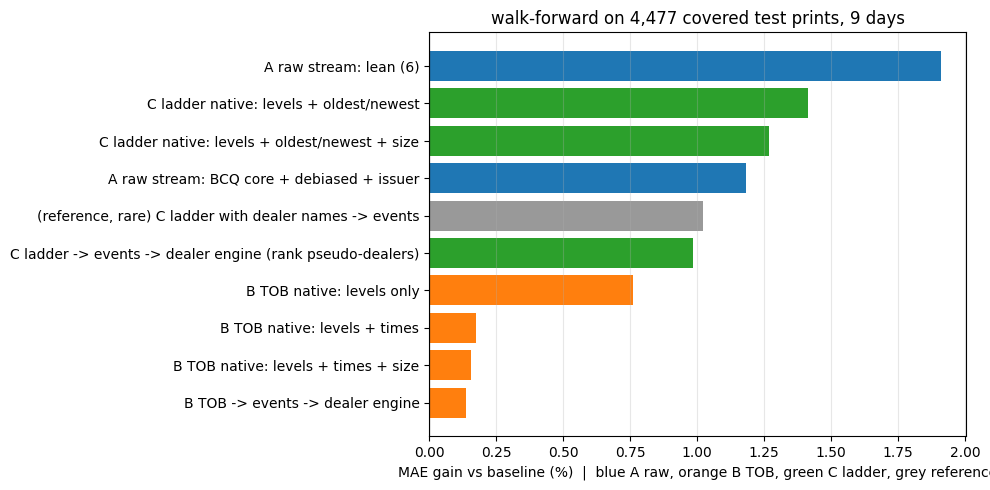

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
r = res.drop(index="baseline (14 features)").sort_values("gain_pct")
colors = ["C0" if v.startswith("A") else "C1" if v.startswith("B") else "C2" if v.startswith("C") else "0.6" for v in r.index]
ax.barh(r.index, r["gain_pct"], color=colors)
ax.axvline(0, color="k", lw=.8); ax.set_xlabel("MAE gain vs baseline (%)  |  blue A raw, orange B TOB, green C ladder, grey reference")
ax.set_title(f"walk-forward on {len(test):,} covered test prints, {test.DATE.nunique()} days"); ax.grid(alpha=.3, axis="x"); plt.tight_layout(); plt.show()

## 6. Summary: what to do with each shape of quote data

**Method**

1. Assume no dealer identity in a snapshot feed and ask which of the other three fields are present: **per-side / per-level update times, size, depth**. They decide whether freshness gating, size features and dispersion features are possible. Dealer identity, if a feed happens to carry it, is a bonus that turns rank-based dynamics back into same-dealer chained moves (§3.3 reference row).
2. Two routes work without identity: route 1 converts the snapshot to events with pseudo-dealers (`TOB`, `L{k}`) and reuses the shape-A engine unchanged (same feature names, dynamics become per-rank); route 2 builds native snapshot features. On this data route 2 on the ladder is the stronger of the two.
3. In any snapshot shape keep: the snapshot delay `SNAP_AGE`, the `max_age` gate on update times, and the `CROSSED` flag (a TOB cannot be uncrossed, only flagged).
4. Move level features into the model's coordinate `X − PREV_BM_SPREAD + offset` and build the CPP-relative versions; this is the only family that is reliably useful in all three shapes. Yield / price quotes are converted to spread before entering the framework.
5. Evaluate the shapes on the **same prints and the same folds**, and read the ordering rather than absolute numbers.

**Data (conclusions for this slice, see the table above; one month of data, ordering not decimals)**

* Shape A's 6-feature lean set (+1.9%, by-day t≈3.5) is the reference ceiling; the full 45 features give only +1.2% — at this sample size more features are noise, in all three shapes;
* the 5-level ladder without dealer names is the best snapshot shape: +1.4% (t≈2.1) from levels + oldest/newest alone, carried by `D_LAD_MID_MED` (the median over levels is far more stable than L1) and CPP's position in the ladder; adding size does not help (+1.3%). Its dynamics are weak: in §3.3 the median of per-rank changes correlates with the target at 0.28 vs 0.39 for same-dealer chained changes. Route 1 with rank pseudo-dealers gives +1.0%, essentially what the same ladder *with* dealer names gives (+1.0%, reference row) — identity would clean up the dynamics but barely moves MAE here;
* the TOB loses the most (+0.1–0.8%, unstable): the best level is often a stale aggressive quote (about 1/3 of two-sided TOBs are crossed), there is no second level to route around it, and there is no dispersion. Levels alone did best; the freshness and size features added noise on this sample — start with "levels + freshness gate + CROSSED" and add the rest only with more data;
* size contributes nothing measurable in this data set (only ~1/4 of BondCliQ TOBs show size, mostly round numbers in MM).

All code used here is defined inline above. The same functions are maintained in `quote_snapshots.py` (conversions, native snapshot features), `bcq_features.py` (event-stream adapters, dealer engine) and `bcq_intraday_eval.py` (evaluation) for use outside the notebook.